In [66]:
# ============================================================
# PHASE 2 : DATA AUDITING & CLEANING
# ============================================================
#
# Goal:
# Ensure that the dataset is clean, complete, and suitable
# for machine learning before any analysis is performed.
#
# This phase includes:
# 1. Dataset overview
# 2. Train-Test consistency
# 3. Missing value analysis
# 4. Duplicate detection
# 5. Data type verification
# 6. Hidden missing values
# 7. Categorical consistency
# ============================================================

# =============================================================================
# STEP 1 : IMPORT REQUIRED LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np

# Display all columns
pd.set_option("display.max_columns", None)

# Display all rows (optional)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 2 : LOAD DATASET
# =============================================================================

# Read the dataset
Data = pd.read_csv("D:\\project\\data\\raw\\CKD_Risk_Progression_Dataset_2026.csv")

print("Dataset loaded successfully.")

print("\nDataset Name : Data")

print("-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 3 : DATASET OVERVIEW
# =============================================================================
#
# Why?
# Understanding the size of the dataset helps us know:
#
# • Number of observations (patients)
# • Number of variables (features)
#
# =============================================================================

rows, columns = Data.shape

print("DATASET DIMENSIONS")
print()

print(f"Number of Patients (Rows)     : {rows}")

print(f"Number of Variables (Columns) : {columns}")

print("\nThe dataset has been loaded successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

# =============================================================================
# STEP 4 : PREVIEW THE DATASET
# =============================================================================
#
# Why?
#
# Looking at the first few observations helps us understand:
#
# • How the data is organized
# • Variable names
# • Possible formatting issues
#
# =============================================================================

print("First Five Observations")

display(Data.head())

print("\n" + "-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 5 : DATASET INFORMATION
# =============================================================================
#
# Why?
#
# This provides:
#
# • Variable names
# • Data types
# • Number of non-missing values
# • Memory usage
#
# =============================================================================

print("DATASET INFORMATION")

Data.info()

print("\n" + "-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 6 : IDENTIFY VARIABLE TYPES
# =============================================================================

numerical_features = Data.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = Data.select_dtypes(
    exclude=np.number
).columns.tolist()

print(f"Numerical Variables   : {len(numerical_features)}")

print(f"Categorical Variables : {len(categorical_features)}")

print("\nNumerical Features")

print(numerical_features)

print("\nCategorical Features")

print(categorical_features)

print("\n" + "-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 7 : DESCRIPTIVE STATISTICS
# =============================================================================
#
# Why?
#
# Descriptive statistics provide an overview of the numerical variables,
# including:
#
# • Mean
# • Standard Deviation
# • Minimum
# • Maximum
# • Quartiles
#
# =============================================================================

display(Data.describe().T)

print("\n" + "-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 8 : MISSING VALUE ANALYSIS
# =============================================================================

missing_report = pd.DataFrame({

    "Missing Values":Data.isnull().sum(),

    "Percentage (%)":round(
        Data.isnull().mean()*100,
        2
    )

})

missing_report = missing_report[
    missing_report["Missing Values"]>0
]

missing_report = missing_report.sort_values(
    by="Missing Values",
    ascending=False
)

print("MISSING VALUE REPORT")

display(missing_report)

print("\n" + "-"*77)

# -----------------------------------------------------------------------------


Libraries imported successfully.

-----------------------------------------------------------------------------
Dataset loaded successfully.

Dataset Name : Data
-----------------------------------------------------------------------------
DATASET DIMENSIONS

Number of Patients (Rows)     : 200000
Number of Variables (Columns) : 82

The dataset has been loaded successfully.

-----------------------------------------------------------------------------
First Five Observations


,Patient_ID,Age,Sex,Ethnicity,Country,Residence_Type,Education_Level,Socioeconomic_Status,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Body_Fat_Percentage,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Exercise_Hours_Per_Week,Daily_Steps,Water_Intake_L,Sodium_Intake_mg,Fast_Food_Frequency_Per_Week,Sleep_Duration_Hours,Stress_Level,Diabetes,Hypertension,Cardiovascular_Disease,Heart_Failure,Hyperlipidemia,Kidney_Stones,Recurrent_UTI,Autoimmune_Disease,Family_History_CKD,Obesity,Heart_Rate,Respiratory_Rate,Oxygen_Saturation,Systolic_BP,Diastolic_BP,Blood_Pressure_Category,Serum_Creatinine,eGFR,Blood_Urea_Nitrogen,Albumin,Urine_ACR,Albuminuria_Category,Urine_Protein,HbA1c,Fasting_Glucose,Hemoglobin,Sodium,Potassium,Calcium,Phosphorus,Uric_Acid,Total_Cholesterol,HDL,LDL,Triglycerides,CRP,ACE_Inhibitor,ARB,Diabetes_Medication,Statin,Diuretic,NSAID_Usage,Medication_Adherence,Number_of_Medications,Frailty_Index,Frailty_Category,Hospital_Visits,Emergency_Visits,Specialist_Visits,Annual_Checkups,Health_Insurance,Annual_Household_Income_USD,Annual_Medical_Cost_USD,Employment_Status,CKD,CKD_Stage,Kidney_Failure_Risk,Dialysis_Required,Hospitalization_Risk
0,1,53,Female,Asian,UK,Rural,High School,Middle,171.3,62.8,21.4,77.2,18.4,Never,NaN,Sedentary,0.3,2862,1.34,3038,3,4.7,Moderate,0,0,0,0,0,0,0,0,0,0,80,14,98.1,102,62,Normal,0.81,86.7,18.4,3.91,7.6,A1,0.0,NaN,78.0,13.1,139.5,4.1,9.5,3.1,6.6,176,38.0,55.0,185,1.88,1,0,1,0,0,1,45,2,0.161,Vulnerable,1,0,1,1,1,72700,2003,Unemployed/Retired,0,Healthy,Low,0,Low
1,2,30,Male,Other,USA,Urban,High School,Middle,180.3,115.4,35.5,104.3,23.8,Never,Moderate,Moderate,4.6,9939,1.45,1300,6,7.1,High,0,0,0,0,0,0,0,0,1,1,83,13,98.4,105,61,Normal,1.01,102.6,14.4,4.44,3.3,A1,0.0,NaN,108.0,14.9,139.8,4.1,9.3,3.3,5.9,182,40.0,73.0,229,0.98,0,0,0,1,0,1,89,1,0.245,Frail,1,0,0,3,1,80800,1103,Employed,0,Healthy,Low,0,Low
2,3,61,Female,White,USA,Rural,Some College,High,171.1,62.6,21.4,65.0,21.9,Never,Moderate,Sedentary,0.3,2867,1.77,3126,1,6.3,Low,0,0,1,0,0,0,0,0,0,0,78,16,98.0,117,61,Normal,0.75,90.5,11.7,4.11,2.7,A1,10.6,4.8,85.0,13.2,138.5,4.0,9.5,3.5,3.8,165,32.0,57.0,138,1.02,0,0,0,0,0,0,38,0,0.215,Frail,1,0,1,0,1,142300,3285,Employed,0,Healthy,Low,0,Low
3,4,64,Female,Hispanic,Other,Rural,Some College,Low,153.3,70.7,30.1,81.5,35.0,Never,Moderate,Sedentary,0.2,2588,1.01,4127,2,6.4,High,1,0,0,0,1,0,0,0,1,1,92,14,98.1,138,77,Hypertension Stage 1,1.16,52.6,20.8,3.88,40.0,A2,44.4,5.2,179.0,14.3,145.5,3.9,9.3,3.6,7.6,214,70.0,71.0,261,4.38,1,0,1,1,0,0,52,3,0.404,Frail,2,2,3,1,0,24100,12113,Employed,1,Stage 3a,Low,0,Moderate
4,5,18,Male,White,UK,Rural,Some College,Middle,174.0,79.0,26.1,88.2,8.0,Never,NaN,Sedentary,0.2,1513,3.09,4446,2,7.0,Low,0,1,0,0,0,0,0,0,0,0,68,13,98.4,138,77,Hypertension Stage 1,1.24,86.4,11.7,4.36,38.8,A2,19.6,NaN,85.0,16.1,142.3,4.2,9.6,NaN,6.7,186,46.0,73.0,145,NaN,1,0,0,0,0,0,65,1,0.160,Vulnerable,1,0,1,0,0,50300,2591,Employed,0,Healthy,Low,0,Low



-----------------------------------------------------------------------------
DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 82 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Patient_ID                    200000 non-null  int64  
 1   Age                           200000 non-null  int64  
 2   Sex                           200000 non-null  str    
 3   Ethnicity                     200000 non-null  str    
 4   Country                       200000 non-null  str    
 5   Residence_Type                200000 non-null  str    
 6   Education_Level               200000 non-null  str    
 7   Socioeconomic_Status          200000 non-null  str    
 8   Height_cm                     200000 non-null  float64
 9   Weight_kg                     200000 non-null  float64
 10  BMI                           200000 non-null  float64
 11  Waist_Circumfere

,count,mean,std,min,25%,50%,75%,max
Patient_ID,200000.0,100000.500000,57735.171256,1.00,50000.750,100000.500,150000.250,200000.00
Age,200000.0,48.236655,16.422735,18.00,37.000,48.000,59.000,95.00
Height_cm,200000.0,168.344836,9.370505,128.10,161.400,168.100,175.200,208.40
Weight_kg,200000.0,79.552561,18.510762,30.50,66.500,78.600,91.600,175.10
BMI,200000.0,27.985165,5.687226,15.00,24.100,28.000,31.800,53.20
Waist_Circumference_cm,183882.0,86.120650,13.414689,55.00,76.800,86.000,95.200,144.30
Body_Fat_Percentage,175892.0,23.275168,9.706560,5.00,16.300,23.100,30.000,60.00
Exercise_Hours_Per_Week,200000.0,1.937117,2.401858,0.00,0.300,1.000,2.700,12.00
Daily_Steps,200000.0,5684.801740,3192.993352,1500.00,3099.000,5058.000,7722.000,15999.00
Water_Intake_L,200000.0,1.800871,0.497249,0.50,1.460,1.800,2.140,4.03



-----------------------------------------------------------------------------
MISSING VALUE REPORT


,Missing Values,Percentage (%)
Phosphorus,74117,37.06
Alcohol_Consumption,71735,35.87
HbA1c,39986,19.99
Albuminuria_Category,34961,17.48
Urine_ACR,34961,17.48
Urine_Protein,34961,17.48
Body_Fat_Percentage,24108,12.05
Waist_Circumference_cm,16118,8.06
Fasting_Glucose,11621,5.81
Calcium,8045,4.02



-----------------------------------------------------------------------------


In [67]:
# =============================================================================
# STEP 9 : CATEGORICAL VARIABLE AUDIT
# =============================================================================

print("Inspecting categorical variables...\n")

categorical_features = Data.select_dtypes(
    exclude=np.number
).columns

for column in categorical_features:

    print("="*60)

    print(f"Variable : {column}")

    print("="*60)

    print(Data[column].value_counts(dropna=False))

    print()

print("-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 10 : NUMERICAL VARIABLE AUDIT
# =============================================================================

print("Summary Statistics for Numerical Variables\n")

display(
    Data.describe().T
)

print("\nChecking for impossible values...")

print("-"*77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 11 : TARGET VARIABLE ANALYSIS
# =============================================================================

TARGET = "CKD_Stage"

print("Distribution of CKD Stages\n")

target_summary = pd.DataFrame({

    "Count":Data[TARGET].value_counts(),

    "Percentage (%)":
    round(
        Data[TARGET].value_counts(normalize=True)*100,
        2
    )

})

display(target_summary)

print("\n" + "-"*77)

#REPORT:The dataset consists of five CKD severity categories. Healthy Kidney represents XX% of the observations, whereas Stage 5 represents XX%.
# -----------------------------------------------------------------------------

Inspecting categorical variables...

Variable : Sex
Sex
Female    101915
Male       98085
Name: count, dtype: int64

Variable : Ethnicity
Ethnicity
White       110307
Hispanic     33820
Black        26025
Asian        19873
Other         9975
Name: count, dtype: int64

Variable : Country
Country
USA          89780
UK           30020
India        29943
Canada       20043
Australia    16284
Other        13930
Name: count, dtype: int64

Variable : Residence_Type
Residence_Type
Urban    123978
Rural     76022
Name: count, dtype: int64

Variable : Education_Level
Education_Level
High School              60239
Some College             51054
Bachelor's               44065
Less than High School    24671
Graduate                 19971
Name: count, dtype: int64

Variable : Socioeconomic_Status
Socioeconomic_Status
Middle    88064
High      61728
Low       50208
Name: count, dtype: int64

Variable : Smoking_Status
Smoking_Status
Never      115313
Former      44053
Current     40634
Name: count, d

,count,mean,std,min,25%,50%,75%,max
Patient_ID,200000.0,100000.500000,57735.171256,1.00,50000.750,100000.500,150000.250,200000.00
Age,200000.0,48.236655,16.422735,18.00,37.000,48.000,59.000,95.00
Height_cm,200000.0,168.344836,9.370505,128.10,161.400,168.100,175.200,208.40
Weight_kg,200000.0,79.552561,18.510762,30.50,66.500,78.600,91.600,175.10
BMI,200000.0,27.985165,5.687226,15.00,24.100,28.000,31.800,53.20
Waist_Circumference_cm,183882.0,86.120650,13.414689,55.00,76.800,86.000,95.200,144.30
Body_Fat_Percentage,175892.0,23.275168,9.706560,5.00,16.300,23.100,30.000,60.00
Exercise_Hours_Per_Week,200000.0,1.937117,2.401858,0.00,0.300,1.000,2.700,12.00
Daily_Steps,200000.0,5684.801740,3192.993352,1500.00,3099.000,5058.000,7722.000,15999.00
Water_Intake_L,200000.0,1.800871,0.497249,0.50,1.460,1.800,2.140,4.03



Checking for impossible values...
-----------------------------------------------------------------------------
Distribution of CKD Stages



,Count,Percentage (%)
CKD_Stage,,
Healthy,162948,81.47
Stage 3a,28213,14.11
Stage 3b,5538,2.77
Stage 4,1308,0.65
Stage 2,1066,0.53
Stage 5,895,0.45
Stage 1,32,0.02



-----------------------------------------------------------------------------


In [68]:
# =============================================================================
# STEP 12 : DATA QUALITY REPORT
# =============================================================================

total_cells = Data.shape[0] * Data.shape[1]
missing_values = Data.isnull().sum().sum()
missing_percentage = (missing_values / total_cells) * 100

print("="*77)
print("                         DATA QUALITY REPORT")
print("="*77)

print(f"Total Observations      : {Data.shape[0]:,}")
print(f"Total Variables         : {Data.shape[1]}")

print("-"*77)

print(f"Numerical Features      : {len(numerical_features)}")
print(f"Categorical Features    : {len(categorical_features)}")

print("-"*77)

print(f"Duplicate Records       : {Data.duplicated().sum():,}")
print(f"Total Missing Values    : {missing_values:,}")
print(f"Missing Percentage      : {missing_percentage:.2f}%")

print("="*77)

print("Interpretation")
print("-"*77)

if missing_percentage < 5:
    print("• Missing data is minimal (<5%) and can be handled through imputation.")
elif missing_percentage < 20:
    print("• Missing data is moderate and requires careful imputation.")
else:
    print("• Missing data is substantial and requires detailed investigation.")

if Data.duplicated().sum() == 0:
    print("• No duplicate observations were detected.")
else:
    print("• Duplicate observations should be removed before analysis.")

print("• The dataset is suitable for further preprocessing and EDA.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                         DATA QUALITY REPORT
Total Observations      : 200,000
Total Variables         : 82
-----------------------------------------------------------------------------
Numerical Features      : 65
Categorical Features    : 17
-----------------------------------------------------------------------------
Duplicate Records       : 0
Total Missing Values    : 370,399
Missing Percentage      : 2.26%
Interpretation
-----------------------------------------------------------------------------
• Missing data is minimal (<5%) and can be handled through imputation.
• No duplicate observations were detected.
• The dataset is suitable for further preprocessing and EDA.

-----------------------------------------------------------------------------


In [69]:
# =============================================================================
# STEP 7 : REMOVE NON-INFORMATIVE VARIABLES
# =============================================================================
#
# Objective:
# Remove variables that serve only as identifiers and do not contribute
# to statistical analysis or predictive modeling.
#
# Patient_ID is a unique identifier assigned to each patient.
# It carries no clinical information and therefore will be excluded
# from all subsequent analyses.
#
# =============================================================================

print("="*77)
print("            REMOVING NON-INFORMATIVE VARIABLES")
print("="*77)

# Remove Patient_ID
Data = Data.drop(columns=["Patient_ID"])

print("'Patient_ID' has been removed successfully.")

print(f"Updated Dataset Shape : {Data.shape}")

# Re-identify feature types
numerical_features = Data.select_dtypes(include="number").columns.tolist()

categorical_features = Data.select_dtypes(exclude="number").columns.tolist()

print(f"Numerical Variables   : {len(numerical_features)}")
print(f"Categorical Variables : {len(categorical_features)}")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

            REMOVING NON-INFORMATIVE VARIABLES
'Patient_ID' has been removed successfully.
Updated Dataset Shape : (200000, 81)
Numerical Variables   : 64
Categorical Variables : 17

-----------------------------------------------------------------------------


In [70]:
# #PHASE 3 : EXPLORATORY DATA ANALYSIS

# 3.1 Target Variable Analysis

# 3.2 Univariate Analysis
#       ├── Numerical Variables
#       └── Categorical Variables

# 3.3 Bivariate Analysis
#       ├── Numerical vs CKD
#       └── Categorical vs CKD

# 3.4 Correlation Analysis

# 3.5 Statistical Association Tests

# 3.6 Key Insights from EDA

# PHASE 3 : EXPLORATORY DATA ANALYSIS

# ✓ Step 15 : Target Variable Analysis
# ✓ Step 16 : Target Variable Visualization

# NEXT

# Step 17 : Univariate Analysis of Numerical Variables
# Step 18 : Univariate Analysis of Categorical Variables
# Step 19 : Bivariate Analysis (Numerical vs Target)
# Step 20 : Bivariate Analysis (Categorical vs Target)
# Step 21 : Correlation Analysis
# Step 22 : Statistical Association Tests
# Step 23 : EDA Summary


In [71]:
# =============================================================================
# STEP 8 : DATA DICTIONARY
# =============================================================================
#
# Objective:
# Create a comprehensive data dictionary describing each variable
# in the dataset.
#
# The dictionary includes:
# • Variable Name
# • Data Type
# • Missing Values
# • Missing Percentage
# • Number of Unique Values
# • Example Values
#
# =============================================================================

print("="*90)
print("                           DATA DICTIONARY")
print("="*90)

data_dictionary = pd.DataFrame({

    "Variable Name": Data.columns,

    "Data Type": Data.dtypes.astype(str),

    "Missing Values": Data.isnull().sum().values,

    "Missing (%)":
    (
        Data.isnull().mean()*100
    ).round(2).values,

    "Unique Values":
    Data.nunique().values,

    "Example Values":[

        ", ".join(
            map(
                str,
                Data[col]
                .dropna()
                .unique()[:3]
            )
        )

        for col in Data.columns

    ]

})

display(data_dictionary)

print("\nTotal Variables :", len(data_dictionary))

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                           DATA DICTIONARY


,Variable Name,Data Type,Missing Values,Missing (%),Unique Values,Example Values
Age,Age,int64,0,0.00,78,"53, 30, 61"
Sex,Sex,str,0,0.00,2,"Female, Male"
Ethnicity,Ethnicity,str,0,0.00,5,"Asian, Other, White"
Country,Country,str,0,0.00,6,"UK, USA, Other"
Residence_Type,Residence_Type,str,0,0.00,2,"Rural, Urban"
Education_Level,Education_Level,str,0,0.00,5,"High School, Some College, Graduate"
Socioeconomic_Status,Socioeconomic_Status,str,0,0.00,3,"Middle, High, Low"
Height_cm,Height_cm,float64,0,0.00,630,"171.3, 180.3, 171.1"
Weight_kg,Weight_kg,float64,0,0.00,1241,"62.8, 115.4, 62.6"
BMI,BMI,float64,0,0.00,355,"21.4, 35.5, 30.1"



Total Variables : 81

-----------------------------------------------------------------------------


In [72]:
# =============================================================================
# STEP 9 : DESCRIPTIVE STATISTICS OF NUMERICAL VARIABLES
# =============================================================================
#
# Objective:
# Generate a detailed statistical summary of all numerical variables.
#
# =============================================================================

print("="*90)
print("          DESCRIPTIVE STATISTICS OF NUMERICAL VARIABLES")
print("="*90)

numerical_summary = pd.DataFrame({

    "Count": Data[numerical_features].count(),

    "Missing": Data[numerical_features].isnull().sum(),

    "Mean": Data[numerical_features].mean(),

    "Median": Data[numerical_features].median(),

    "Std Dev": Data[numerical_features].std(),

    "Variance": Data[numerical_features].var(),

    "Minimum": Data[numerical_features].min(),

    "25%": Data[numerical_features].quantile(0.25),

    "75%": Data[numerical_features].quantile(0.75),

    "Maximum": Data[numerical_features].max(),

    "Range":
    Data[numerical_features].max()
    -
    Data[numerical_features].min(),

    "IQR":
    Data[numerical_features].quantile(0.75)
    -
    Data[numerical_features].quantile(0.25),

    "Skewness": Data[numerical_features].skew(),

    "Kurtosis": Data[numerical_features].kurt()

})

display(
    numerical_summary.round(2)
)

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

          DESCRIPTIVE STATISTICS OF NUMERICAL VARIABLES


,Count,Missing,Mean,Median,Std Dev,Variance,Minimum,25%,75%,Maximum,Range,IQR,Skewness,Kurtosis
Age,200000,0,48.24,48.00,16.42,2.697100e+02,18.00,37.00,59.00,95.00,77.00,22.00,0.18,-0.39
Height_cm,200000,0,168.34,168.10,9.37,8.781000e+01,128.10,161.40,175.20,208.40,80.30,13.80,0.08,-0.45
Weight_kg,200000,0,79.55,78.60,18.51,3.426500e+02,30.50,66.50,91.60,175.10,144.60,25.10,0.33,0.06
BMI,200000,0,27.99,28.00,5.69,3.234000e+01,15.00,24.10,31.80,53.20,38.20,7.70,0.09,-0.21
Waist_Circumference_cm,183882,16118,86.12,86.00,13.41,1.799500e+02,55.00,76.80,95.20,144.30,89.30,18.40,0.09,-0.21
Body_Fat_Percentage,175892,24108,23.28,23.10,9.71,9.422000e+01,5.00,16.30,30.00,60.00,55.00,13.70,0.15,-0.42
Exercise_Hours_Per_Week,200000,0,1.94,1.00,2.40,5.770000e+00,0.00,0.30,2.70,12.00,12.00,2.40,2.04,4.21
Daily_Steps,200000,0,5684.80,5058.00,3192.99,1.019521e+07,1500.00,3099.00,7722.00,15999.00,14499.00,4623.00,0.93,0.49
Water_Intake_L,200000,0,1.80,1.80,0.50,2.500000e-01,0.50,1.46,2.14,4.03,3.53,0.68,0.04,-0.10
Sodium_Intake_mg,200000,0,3535.50,3533.00,715.97,5.126164e+05,1000.00,3050.00,4018.00,6500.00,5500.00,968.00,0.02,-0.02



-----------------------------------------------------------------------------


In [73]:
# =============================================================================
# STEP 10 : SUMMARY OF CATEGORICAL VARIABLES
# =============================================================================
#
# Objective:
# Summarize all categorical variables present in the dataset.
#
# =============================================================================

print("="*90)
print("            SUMMARY OF CATEGORICAL VARIABLES")
print("="*90)

categorical_summary = pd.DataFrame({

    "Missing Values":
    Data[categorical_features].isnull().sum(),

    "Unique Categories":
    Data[categorical_features].nunique(),

    "Most Frequent Category":
    Data[categorical_features].mode().iloc[0]

})

display(categorical_summary)

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

            SUMMARY OF CATEGORICAL VARIABLES


,Missing Values,Unique Categories,Most Frequent Category
Sex,0,2,Female
Ethnicity,0,5,White
Country,0,6,USA
Residence_Type,0,2,Urban
Education_Level,0,5,High School
Socioeconomic_Status,0,3,Middle
Smoking_Status,0,3,Never
Alcohol_Consumption,71735,2,Moderate
Physical_Activity_Level,0,4,Sedentary
Stress_Level,0,3,Moderate



-----------------------------------------------------------------------------


                    TARGET VARIABLE ANALYSIS


,CKD Stage,Count,Percentage (%)
0,Healthy,162948,81.47
1,Stage 3a,28213,14.11
2,Stage 3b,5538,2.77
3,Stage 4,1308,0.65
4,Stage 2,1066,0.53
5,Stage 5,895,0.45
6,Stage 1,32,0.02



Total Classes : 7

-----------------------------------------------------------------------------


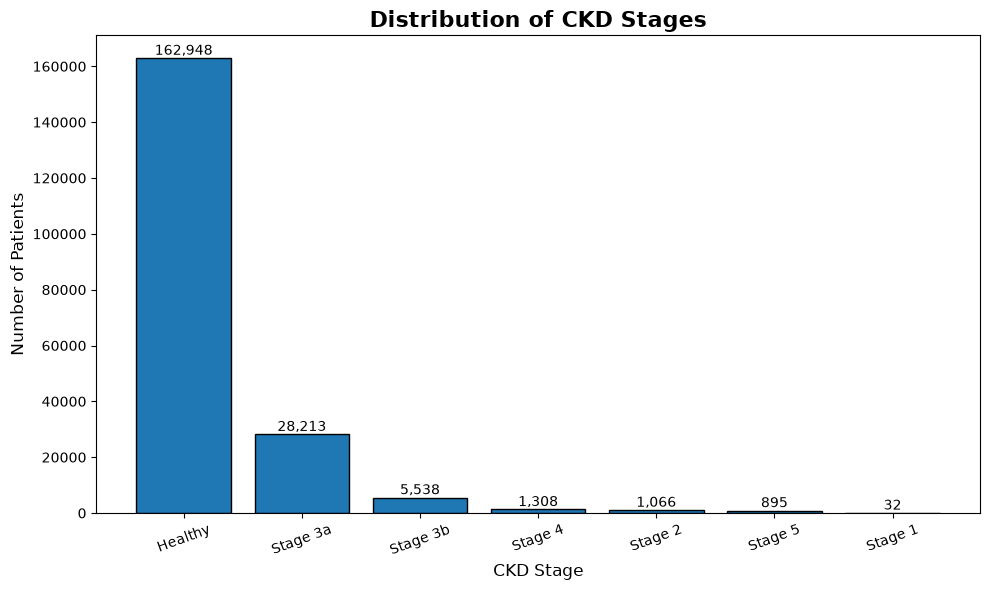


-----------------------------------------------------------------------------


In [74]:
# =============================================================================
# STEP 15 : TARGET VARIABLE ANALYSIS
# =============================================================================
#
# Objective:
# Analyze the distribution of the target variable (CKD Stage) to understand
# the frequency and proportion of each disease stage in the dataset.
#
# Understanding the target variable helps:
# • Identify class imbalance
# • Understand disease prevalence
# • Guide model evaluation strategies
#
# =============================================================================

# Define the target variable
TARGET = "CKD_Stage"

print("=" * 77)
print("                    TARGET VARIABLE ANALYSIS")
print("=" * 77)

# Frequency and percentage table
target_summary = (
    Data[TARGET]
    .value_counts(dropna=False)
    .rename_axis("CKD Stage")
    .reset_index(name="Count")
)

target_summary["Percentage (%)"] = (
    target_summary["Count"] /
    target_summary["Count"].sum() * 100
).round(2)

display(target_summary)

print("\nTotal Classes :", target_summary.shape[0])

print("\n" + "-" * 77)

# -----------------------------------------------------------------------------
# =============================================================================
# STEP 16 : TARGET VARIABLE VISUALIZATION
# =============================================================================
#
# Objective:
# Visualize the distribution of CKD stages using a bar chart.
#
# =============================================================================

import matplotlib.pyplot as plt

# Get counts
counts = Data[TARGET].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    counts.index,
    counts.values,
    edgecolor="black"
)

plt.title(
    "Distribution of CKD Stages",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("CKD Stage", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.xticks(rotation=20)

# Display count on each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

print("\n" + "-" * 77)

# -----------------------------------------------------------------------------

### Interpretation

The target variable represents the stage of Chronic Kidney Disease (CKD) for each patient in the dataset.

The frequency distribution indicates that the dataset is **highly imbalanced**.

- **Healthy** individuals constitute the majority of the dataset with **162,948 patients (81.47%)**.
- **Stage 3a** is the most common CKD class with **28,213 patients (14.11%)**.
- **Stage 3b** accounts for **5,538 patients (2.77%)**.
- **Stage 4**, **Stage 2**, and **Stage 5** are relatively uncommon, representing **1,308 (0.65%)**, **1,066 (0.53%)**, and **895 (0.45%)** patients, respectively.
- **Stage 1** is the rarest class with only **32 patients (0.02%)**.

Overall, approximately **81.47%** of the observations correspond to healthy individuals, while only **18.53%** belong to one of the CKD stages. This substantial class imbalance should be considered during model development, as standard machine learning algorithms may become biased toward the majority class.

For the **Early CKD Screening** model, the multiclass target will later be converted into a **binary outcome** (*Healthy* vs. *CKD*). Nevertheless, the imbalance between healthy and diseased individuals should still be evaluated, and techniques such as **class weighting** or other imbalance-handling strategies may be considered during model training if required.

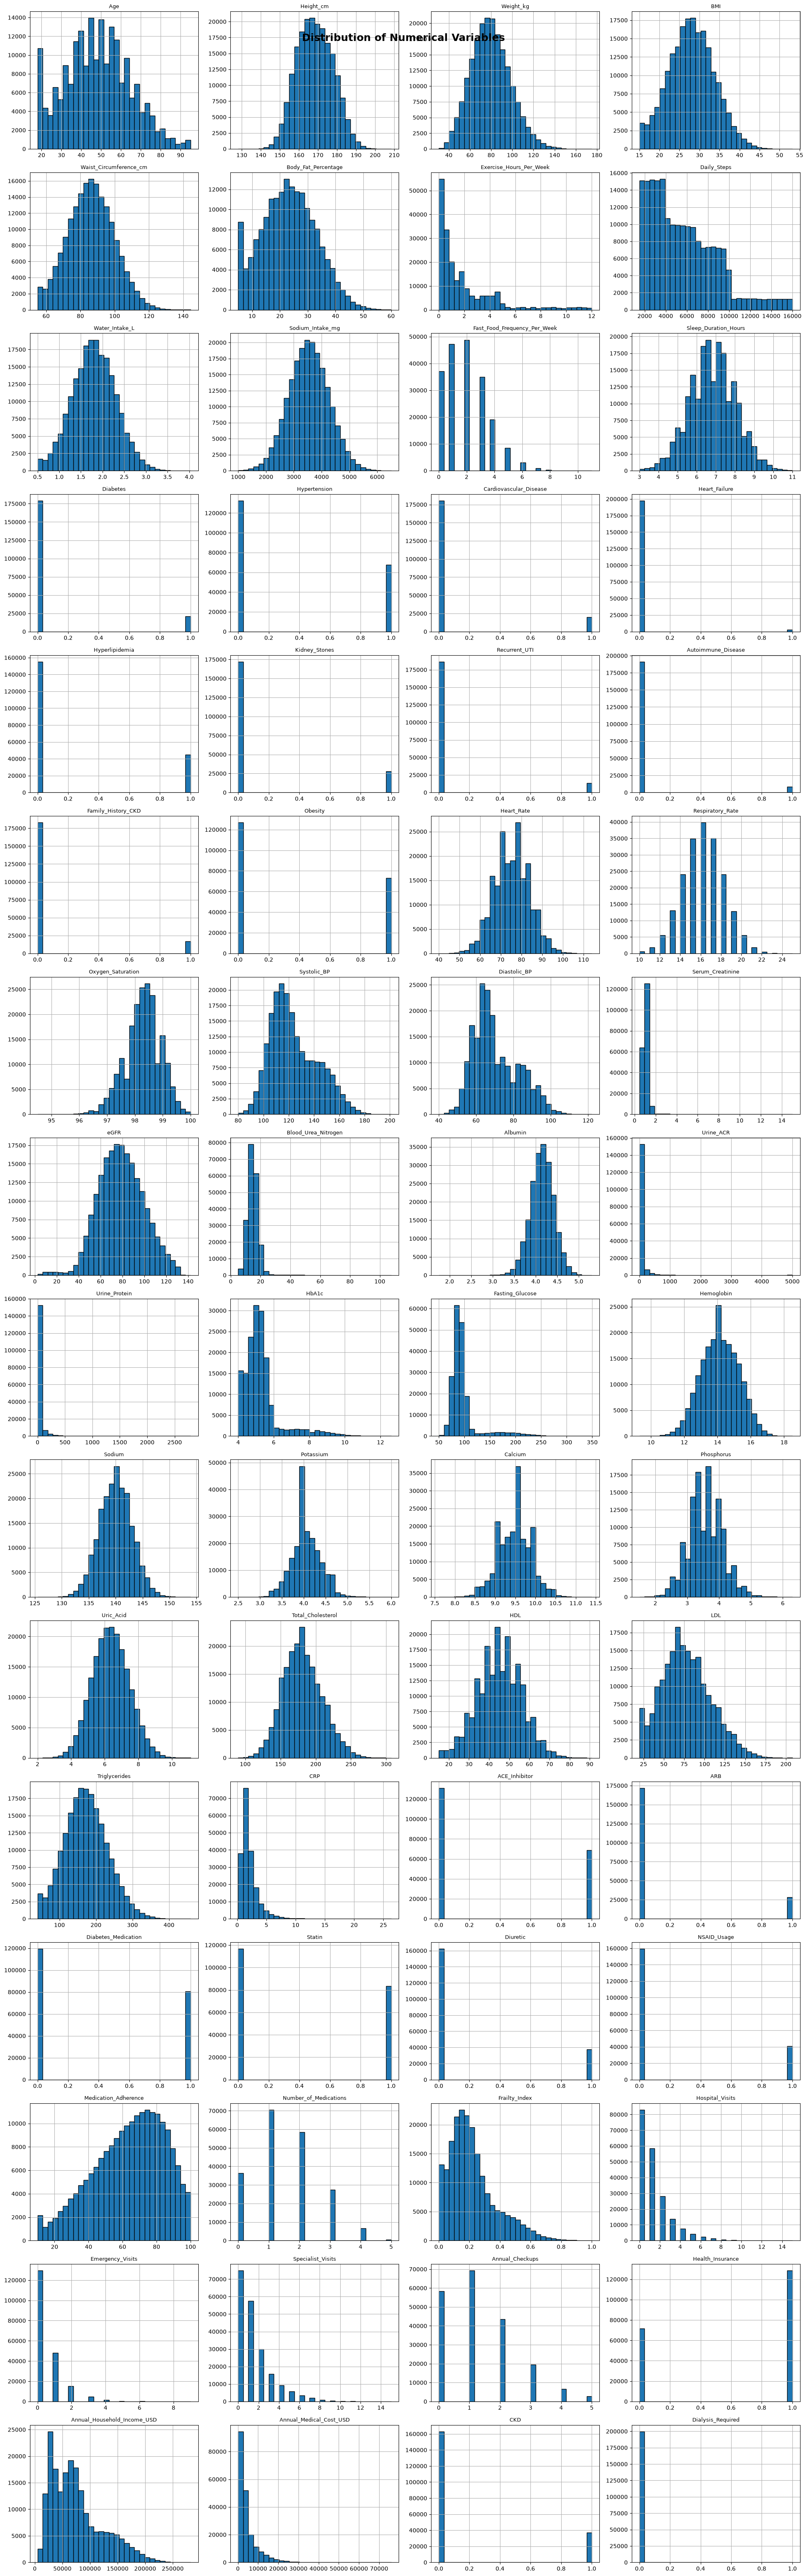


-----------------------------------------------------------------------------


In [75]:
# =============================================================================
# STEP 19 : DISTRIBUTION OF NUMERICAL VARIABLES
# =============================================================================
#
# Objective:
# Visualize the distribution of all numerical variables to understand
# their shape, spread, skewness, and potential abnormalities.
#
# =============================================================================

import matplotlib.pyplot as plt

n_features = len(numerical_features)

n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4*n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    Data[feature].dropna().hist(
        bins=30,
        ax=axes[i],
        edgecolor="black"
    )

    axes[i].set_title(feature, fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

### Interpretation

The histograms illustrate the distribution of all numerical variables in the
dataset.

Visual inspection of these distributions helps identify variables that are
normally distributed, positively or negatively skewed, multimodal, or affected
by extreme values. Such information is valuable when selecting appropriate
statistical tests and deciding whether variable transformations are required
during preprocessing.

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_28228\2187209999.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_28228\2187209999.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_28228\2187209999.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_28228\2187209999.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

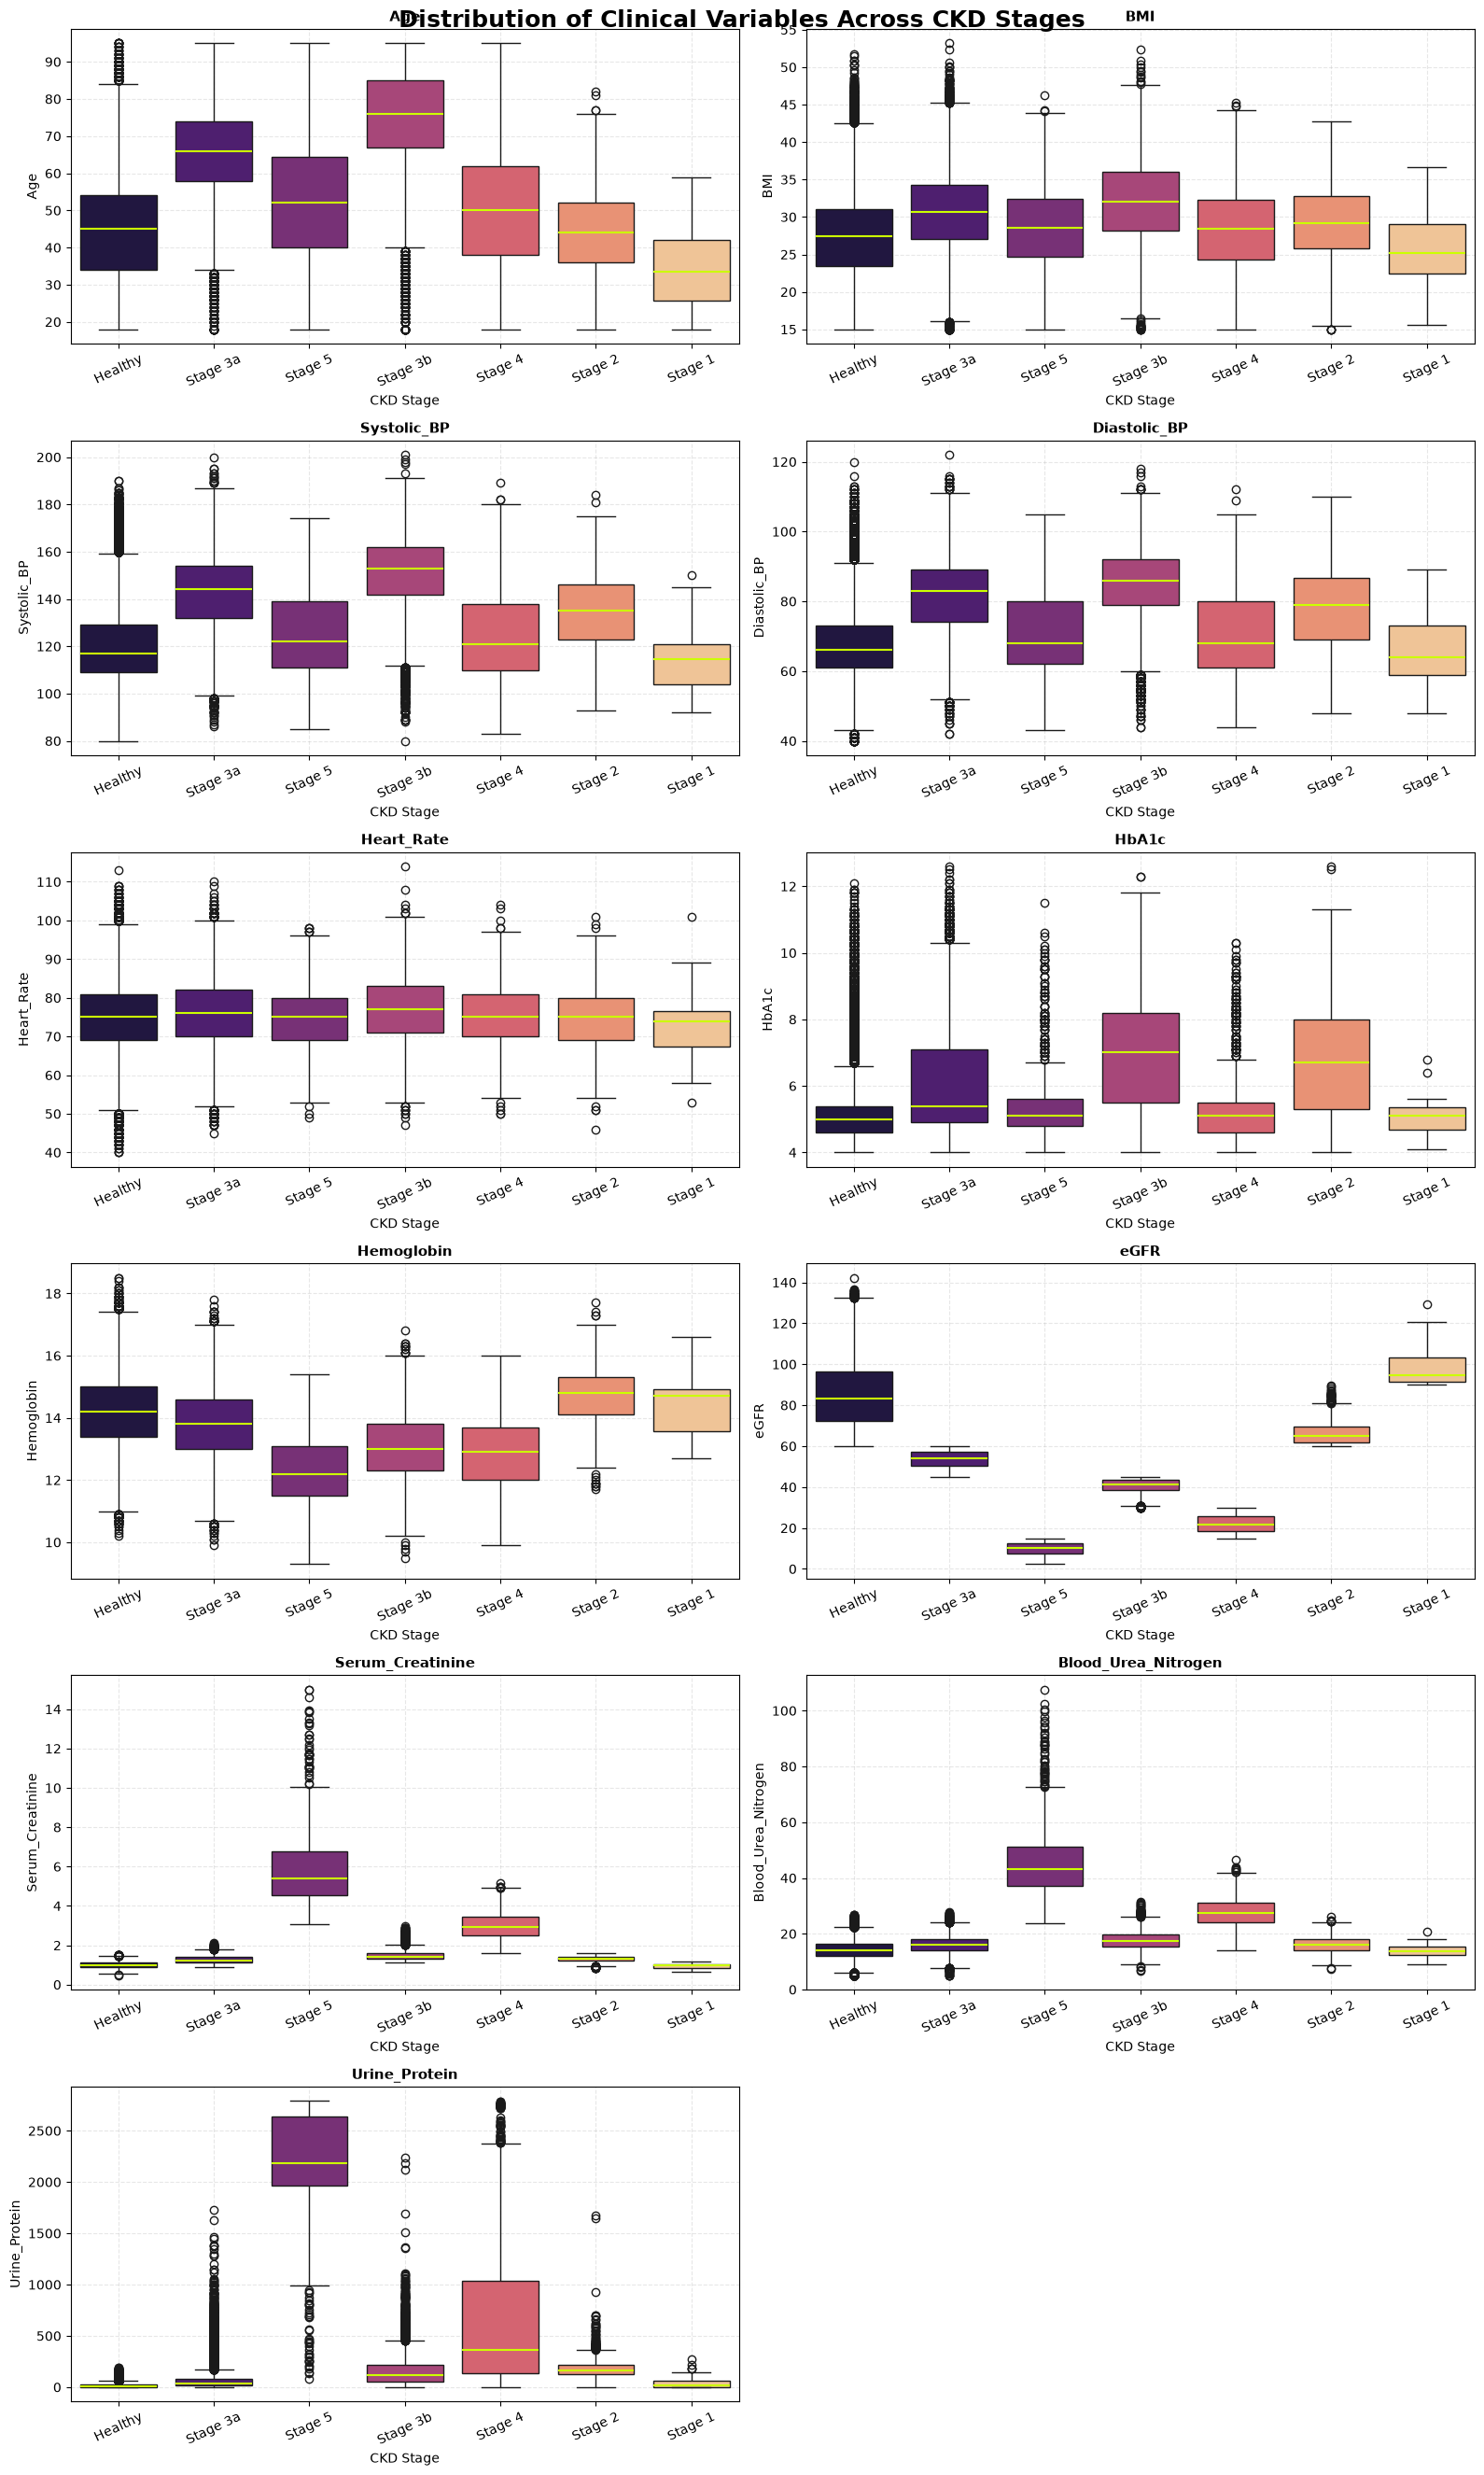


-----------------------------------------------------------------------------


In [76]:
# =============================================================================
# STEP 20 : CLINICAL VARIABLES ACROSS CKD STAGES
# =============================================================================
#
# Objective:
# Visualize how important clinical variables vary across CKD stages.
#
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

TARGET = "CKD_Stage"

clinical_variables = [

    "Age",
    "BMI",

    "Systolic_BP",
    "Diastolic_BP",

    "Heart_Rate",

    "Fasting_Blood_Glucose",
    "HbA1c",

    "Hemoglobin",

    "eGFR",
    "Serum_Creatinine",
    "Blood_Urea_Nitrogen",

    "Urine_Albumin",
    "Urine_Protein",
    "Albumin_Creatinine_Ratio"

]

# Keep only variables available in dataset
clinical_variables = [
    col for col in clinical_variables
    if col in Data.columns
]

# Publication-quality colour palette
palette = "magma"

n_cols = 2
n_rows = (len(clinical_variables) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 4.5)
)

axes = axes.flatten()

for i, feature in enumerate(clinical_variables):

    sns.boxplot(

        data=Data,

        x=TARGET,

        y=feature,

        palette=palette,

        ax=axes[i],

        medianprops={
        "color": "#CCFF00",
        "linewidth": 1.5
    }

    )

    axes[i].set_title(
        feature,
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xlabel("CKD Stage")
    axes[i].set_ylabel(feature)

    axes[i].tick_params(
        axis="x",
        rotation=25
    )

    axes[i].grid(
        alpha=0.30,
        linestyle="--"
    )

# Remove unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(

    "Distribution of Clinical Variables Across CKD Stages",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

In [77]:
# =============================================================================
# STEP 21 : CLASSIFICATION OF NUMERICAL VARIABLES
# =============================================================================
#
# Objective:
# Classify numerical variables into:
# • Continuous Variables
# • Discrete Variables
# • Binary Variables
#
# Binary variables will be excluded from outlier detection because
# IQR-based methods are not suitable for dichotomous data.
#
# =============================================================================

binary_features = []

continuous_features = []

discrete_features = []

for feature in numerical_features:

    unique_values = Data[feature].dropna().nunique()

    if unique_values == 2:

        binary_features.append(feature)

    elif unique_values <= 15:

        discrete_features.append(feature)

    else:

        continuous_features.append(feature)

print("="*90)
print("               NUMERICAL VARIABLE CLASSIFICATION")
print("="*90)

print(f"Continuous Variables : {len(continuous_features)}")

print(f"Discrete Variables   : {len(discrete_features)}")

print(f"Binary Variables     : {len(binary_features)}")

print("\nBinary Variables")
print("-"*90)

print(binary_features)

print("\n" + "-"*77)
print(discrete_features)


# =============================================================================
# STEP 22 : OUTLIER ANALYSIS USING IQR METHOD
# =============================================================================
#
# Objective:
# Identify potential outliers in continuous and discrete variables
# using the Interquartile Range (IQR) method.
#
# Binary variables are excluded.
#
# =============================================================================

outlier_results = []

analysis_features = continuous_features + discrete_features

for feature in analysis_features:

    Q1 = Data[feature].quantile(0.25)

    Q3 = Data[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)

    upper_bound = Q3 + (1.5 * IQR)

    outliers = Data[
        (Data[feature] < lower_bound) |
        (Data[feature] > upper_bound)
    ]

    outlier_results.append({

        "Variable": feature,

        "Outlier Count": len(outliers),

        "Outlier Percentage (%)":
        round((len(outliers) / len(Data)) * 100, 2)

    })

# Create summary table
outlier_summary = pd.DataFrame(outlier_results)

outlier_summary = outlier_summary.sort_values(

    by="Outlier Percentage (%)",

    ascending=False

).reset_index(drop=True)

print("="*90)
print("                     OUTLIER ANALYSIS")
print("="*90)

display(outlier_summary)

print("\n" + "-"*77)
outlier_summary.head(20)
display(outlier_summary.head(20))
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------

               NUMERICAL VARIABLE CLASSIFICATION
Continuous Variables : 41
Discrete Variables   : 4
Binary Variables     : 19

Binary Variables
------------------------------------------------------------------------------------------
['Diabetes', 'Hypertension', 'Cardiovascular_Disease', 'Heart_Failure', 'Hyperlipidemia', 'Kidney_Stones', 'Recurrent_UTI', 'Autoimmune_Disease', 'Family_History_CKD', 'Obesity', 'ACE_Inhibitor', 'ARB', 'Diabetes_Medication', 'Statin', 'Diuretic', 'NSAID_Usage', 'Health_Insurance', 'CKD', 'Dialysis_Required']

-----------------------------------------------------------------------------
['Fast_Food_Frequency_Per_Week', 'Number_of_Medications', 'Emergency_Visits', 'Annual_Checkups']
                     OUTLIER ANALYSIS


,Variable,Outlier Count,Outlier Percentage (%)
0,Urine_ACR,19685,9.84
1,Annual_Medical_Cost_USD,17823,8.91
2,Fasting_Glucose,17325,8.66
3,Urine_Protein,14699,7.35
4,HbA1c,14167,7.08
5,Exercise_Hours_Per_Week,12724,6.36
6,CRP,11812,5.91
7,Frailty_Index,8581,4.29
8,Specialist_Visits,7112,3.56
9,Number_of_Medications,7125,3.56



-----------------------------------------------------------------------------


,Variable,Outlier Count,Outlier Percentage (%)
0,Urine_ACR,19685,9.84
1,Annual_Medical_Cost_USD,17823,8.91
2,Fasting_Glucose,17325,8.66
3,Urine_Protein,14699,7.35
4,HbA1c,14167,7.08
5,Exercise_Hours_Per_Week,12724,6.36
6,CRP,11812,5.91
7,Frailty_Index,8581,4.29
8,Specialist_Visits,7112,3.56
9,Number_of_Medications,7125,3.56


In [78]:
# =============================================================================
# STEP 23 : TOP VARIABLES WITH HIGHEST OUTLIER PERCENTAGES
# =============================================================================
#
# Objective:
# Identify variables containing the largest proportions of outliers.
#
# =============================================================================

print("="*90)
print("              TOP VARIABLES WITH HIGHEST OUTLIER PERCENTAGES")
print("="*90)

top_outliers = (

    outlier_summary

    .sort_values(

        by="Outlier Percentage (%)",

        ascending=False

    )

    .head(20)

)

display(top_outliers)

print("\nTop outlier variables identified successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

              TOP VARIABLES WITH HIGHEST OUTLIER PERCENTAGES


,Variable,Outlier Count,Outlier Percentage (%)
0,Urine_ACR,19685,9.84
1,Annual_Medical_Cost_USD,17823,8.91
2,Fasting_Glucose,17325,8.66
3,Urine_Protein,14699,7.35
4,HbA1c,14167,7.08
5,Exercise_Hours_Per_Week,12724,6.36
6,CRP,11812,5.91
7,Frailty_Index,8581,4.29
8,Specialist_Visits,7112,3.56
9,Number_of_Medications,7125,3.56



Top outlier variables identified successfully.

-----------------------------------------------------------------------------


In [79]:
# =============================================================================
# STEP 24 : CORRELATION MATRIX
# =============================================================================
#
# Objective:
# Compute Pearson correlation coefficients among all numerical variables.
#
# =============================================================================

print("="*90)
print("                     CORRELATION MATRIX")
print("="*90)

correlation_matrix = Data[numerical_features].corr(
    method="pearson"
)

display(correlation_matrix.round(2))

print(f"\nTotal Numerical Variables : {len(numerical_features)}")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                     CORRELATION MATRIX


,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Body_Fat_Percentage,Exercise_Hours_Per_Week,Daily_Steps,Water_Intake_L,Sodium_Intake_mg,Fast_Food_Frequency_Per_Week,Sleep_Duration_Hours,Diabetes,Hypertension,Cardiovascular_Disease,Heart_Failure,Hyperlipidemia,Kidney_Stones,Recurrent_UTI,Autoimmune_Disease,Family_History_CKD,Obesity,Heart_Rate,Respiratory_Rate,Oxygen_Saturation,Systolic_BP,Diastolic_BP,Serum_Creatinine,eGFR,Blood_Urea_Nitrogen,Albumin,Urine_ACR,Urine_Protein,HbA1c,Fasting_Glucose,Hemoglobin,Sodium,Potassium,Calcium,Phosphorus,Uric_Acid,Total_Cholesterol,HDL,LDL,Triglycerides,CRP,ACE_Inhibitor,ARB,Diabetes_Medication,Statin,Diuretic,NSAID_Usage,Medication_Adherence,Number_of_Medications,Frailty_Index,Hospital_Visits,Emergency_Visits,Specialist_Visits,Annual_Checkups,Health_Insurance,Annual_Household_Income_USD,Annual_Medical_Cost_USD,CKD,Dialysis_Required
Age,1.00,-0.00,0.07,0.08,0.08,0.44,-0.11,-0.11,0.00,0.01,0.01,0.00,0.21,0.31,0.29,0.13,0.23,0.12,0.05,-0.00,0.04,0.06,0.04,-0.00,-0.09,0.52,0.37,0.21,-0.75,0.15,-0.12,0.08,0.08,0.17,0.18,-0.09,-0.0,0.12,-0.04,0.11,0.09,0.16,-0.02,0.16,0.09,0.25,0.21,0.07,0.08,0.15,0.09,0.00,-0.03,0.26,0.66,0.34,0.23,0.36,0.10,-0.00,-0.01,0.40,0.50,0.02
Height_cm,-0.00,1.00,0.48,-0.00,0.15,-0.38,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.01,0.01,0.01,-0.00,-0.00,0.06,-0.09,-0.04,0.00,-0.00,-0.00,0.00,-0.05,0.00,0.00,0.16,0.05,0.12,-0.04,0.03,0.03,0.00,0.01,0.46,-0.0,-0.01,0.00,-0.01,0.34,0.00,-0.18,0.05,0.03,0.01,-0.01,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.02,-0.02,-0.02,-0.02,-0.01,0.00,-0.00,-0.03,-0.05,-0.01
Weight_kg,0.07,0.48,1.00,0.87,0.88,0.44,-0.19,-0.21,-0.00,0.05,0.10,-0.00,0.14,0.16,0.10,0.03,0.12,0.09,-0.03,-0.02,0.01,0.69,0.02,0.00,-0.05,0.27,0.31,0.23,-0.27,0.16,-0.10,0.07,0.06,0.13,0.12,0.19,-0.0,0.05,-0.02,0.04,0.46,0.22,-0.31,0.24,0.31,0.29,0.09,0.03,0.05,0.07,0.04,0.01,-0.05,0.12,0.32,0.14,0.11,0.12,0.01,-0.07,-0.14,0.14,0.17,0.00
BMI,0.08,-0.00,0.87,1.00,0.93,0.72,-0.22,-0.24,-0.00,0.05,0.12,-0.00,0.15,0.18,0.10,0.03,0.13,0.07,0.01,-0.00,0.01,0.79,0.02,-0.00,-0.03,0.30,0.35,0.17,-0.34,0.12,-0.09,0.06,0.06,0.15,0.13,-0.04,-0.0,0.06,-0.02,0.05,0.34,0.25,-0.26,0.25,0.34,0.32,0.11,0.04,0.06,0.08,0.05,0.02,-0.06,0.14,0.38,0.17,0.14,0.15,0.02,-0.08,-0.16,0.18,0.23,0.01
Waist_Circumference_cm,0.08,0.15,0.88,0.93,1.00,0.55,-0.21,-0.22,-0.00,0.05,0.11,-0.00,0.14,0.17,0.10,0.03,0.12,0.09,-0.02,-0.01,0.01,0.73,0.02,-0.00,-0.04,0.29,0.33,0.21,-0.30,0.15,-0.10,0.07,0.06,0.14,0.13,0.11,-0.0,0.05,-0.02,0.05,0.42,0.23,-0.30,0.24,0.32,0.30,0.10,0.03,0.06,0.07,0.04,0.02,-0.06,0.13,0.35,0.16,0.12,0.14,0.02,-0.07,-0.15,0.16,0.20,0.01
Body_Fat_Percentage,0.44,-0.38,0.44,0.72,0.55,1.00,-0.19,-0.20,-0.00,0.04,0.09,-0.00,0.18,0.23,0.17,0.07,0.18,0.05,0.10,0.03,0.02,0.57,0.03,-0.00,-0.01,0.40,0.37,0.06,-0.55,0.05,-0.07,0.05,0.05,0.17,0.16,-0.43,-0.0,0.10,-0.04,0.09,0.00,0.23,-0.05,0.19,0.24,0.31,0.17,0.05,0.07,0.11,0.06,0.01,-0.05,0.20,0.53,0.27,0.20,0.26,0.06,-0.05,-0.11,0.30,0.39,0.02
Exercise_Hours_Per_Week,-0.11,-0.00,-0.19,-0.22,-0.21,-0.19,1.00,0.88,-0.00,-0.08,-0.07,-0.00,-0.08,-0.10,-0.05,-0.02,-0.08,-0.03,-0.01,0.00,-0.01,-0.16,-0.01,0.00,0.02,-0.15,-0.14,-0.06,0.16,-0.05,0.05,-0.03,-0.02,-0.07,-0.07,0.01,0.0,-0.02,0.01,-0.02,-0.08,-0.08,0.06,-0.08,-0.09,-0.10,-0.06,-0.02,-0.03,-0.05,-0.03,-0.01,0.04,-0.08,-0.39,-0.09,-0.07,-0.07,0.00,0.05,0.12,-0.08,-0.10,-0.00
Daily_Steps,-0.11,-0.00,-0.21,-0.24,-0.22,-0.20,0.88,1.00,-0.00,-0.10,-0.07,0.00,-0.09,-0.12,-0.06,-0.02,-0.09,-0.03,-0.01,0.00,-0.01,-0.18,-0.01,0.00,0.02,-0.16,-0.16,-0.07,0.17,-0.05,0.05,-0.03,-0.03,-0.08,-0.08,0.02,0.0,-0.03,0.01,-0.03,-0.09,-0.10,0.06,-0.10,-0.10,-0.11,-0.06,-0.02,-0.04,-0.05,-0.03,-0.01,0.04,-0.09,-0.43,-0.10,-0.07,-0.08,0.00,0.06,0.13,-0.09,-0.12,-0.00
Water_Intake_L,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,1.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.25,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.0,-0.00,-0.00,0.00,0.00,-0


Total Numerical Variables : 64

-----------------------------------------------------------------------------


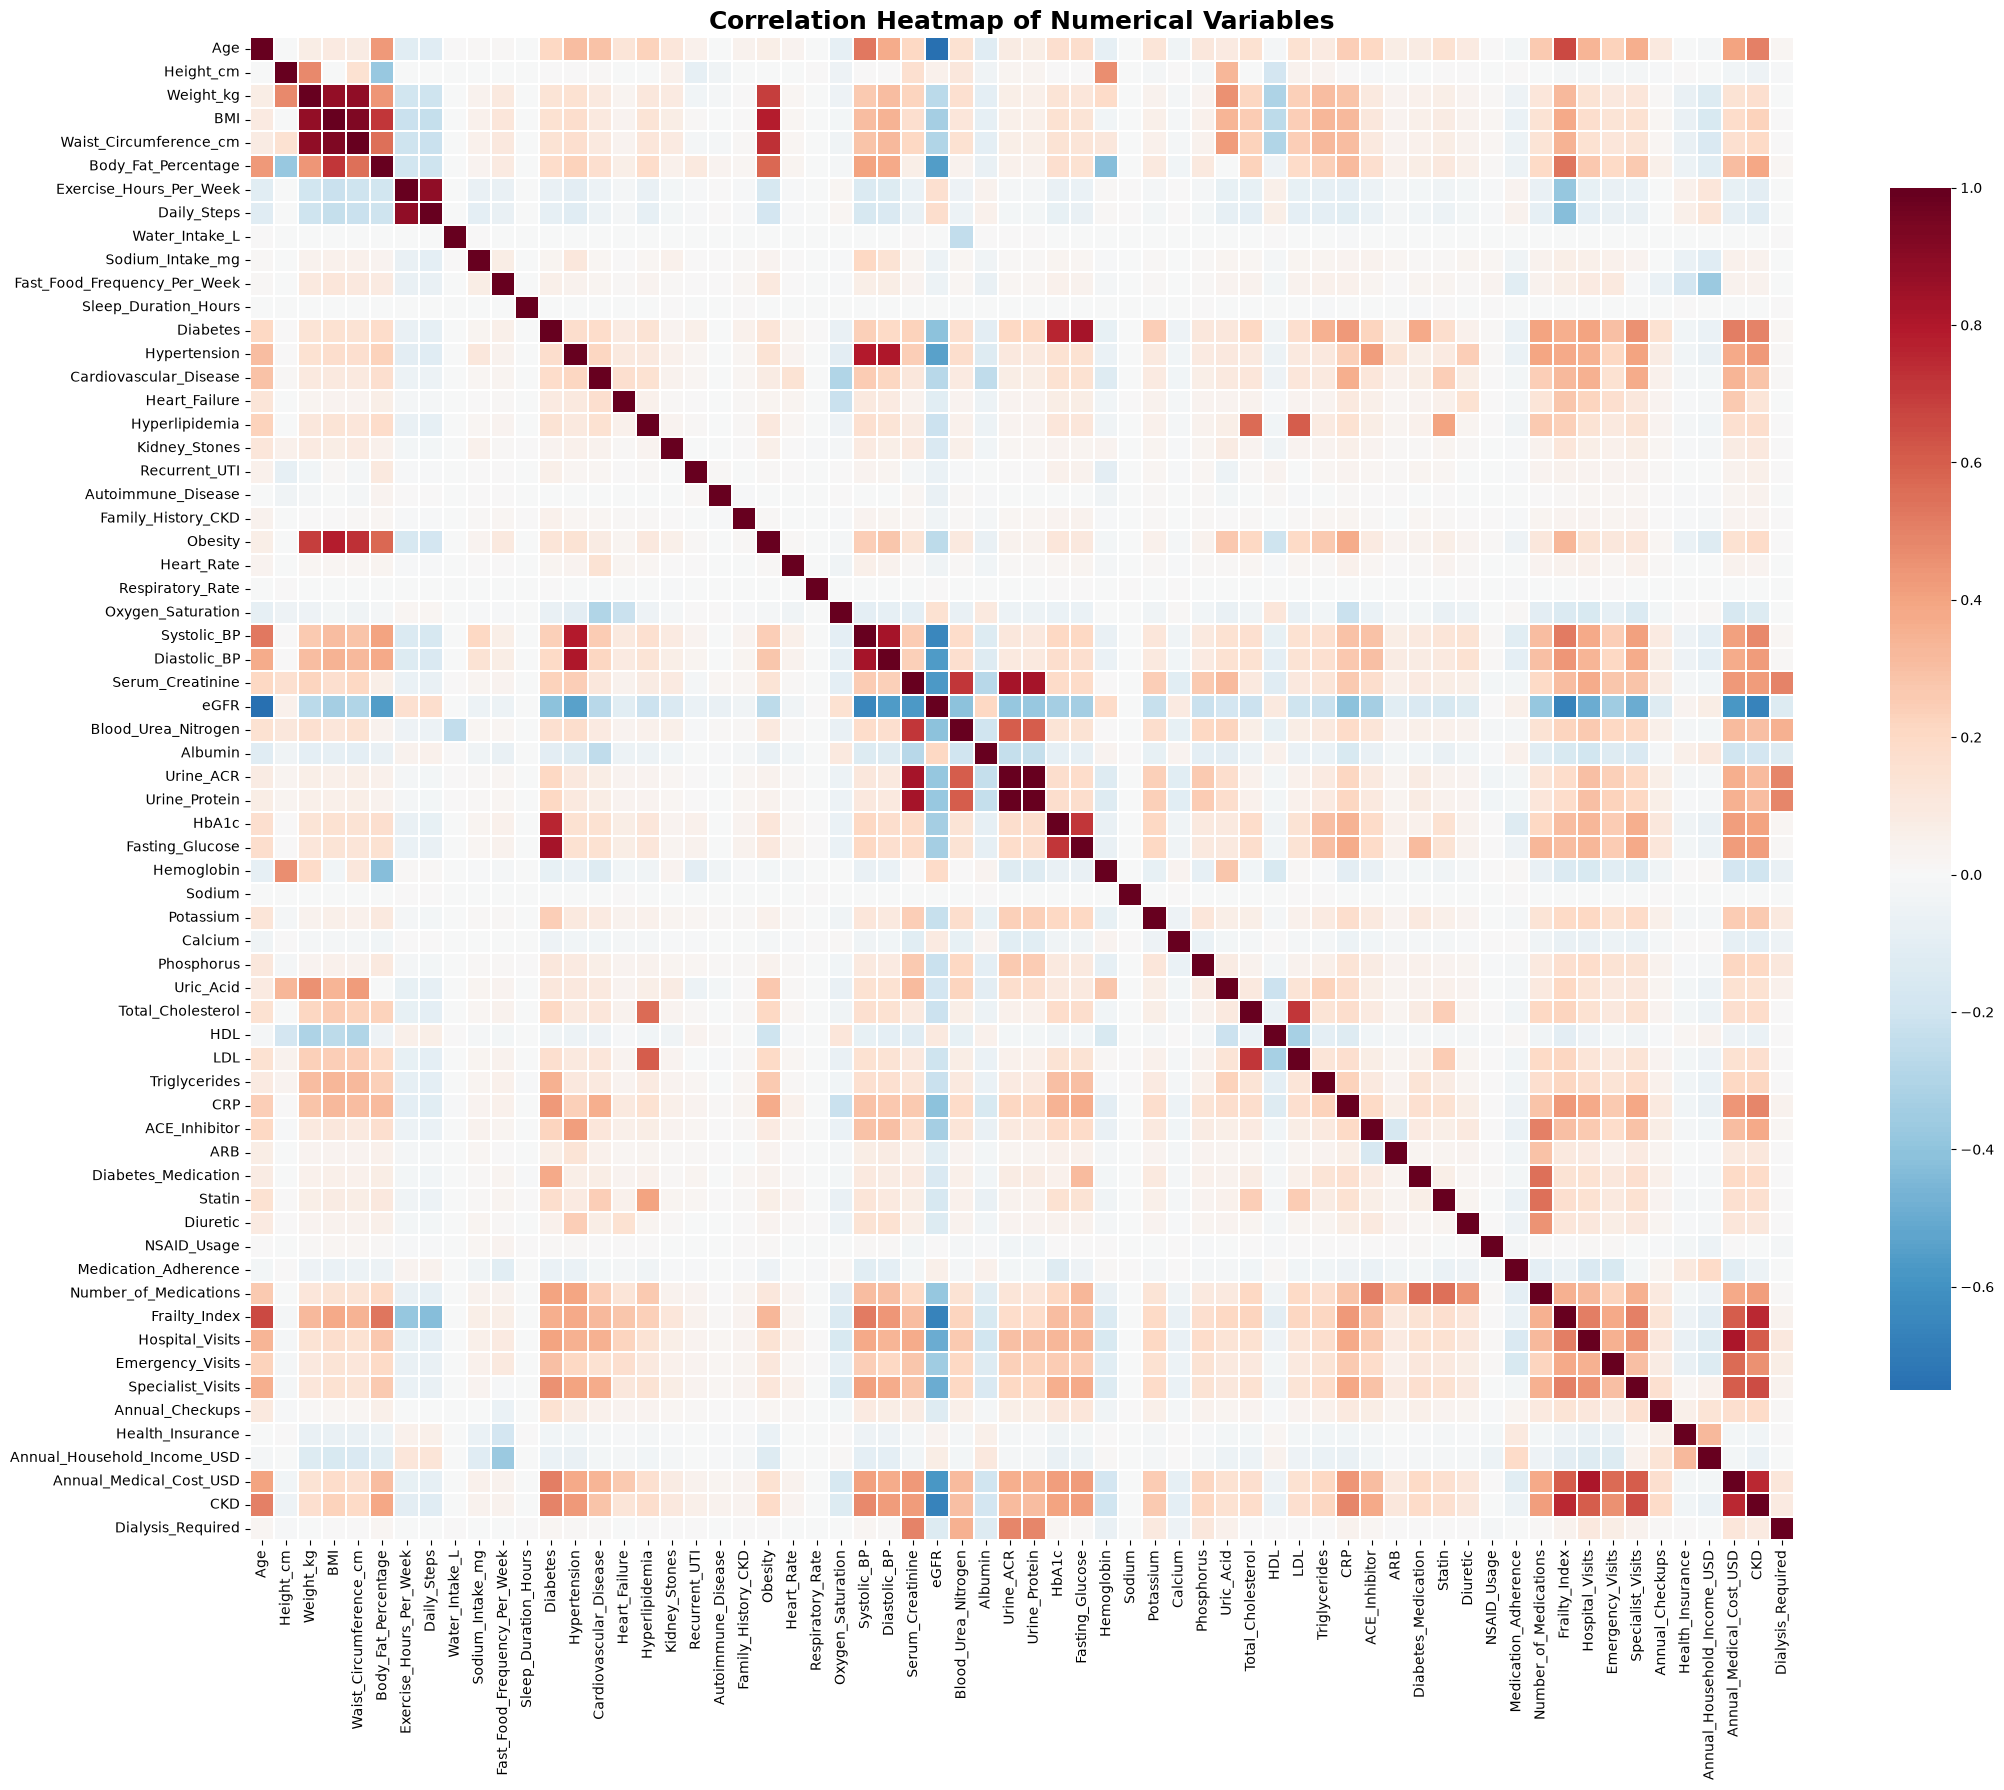


Correlation heatmap generated successfully.

-----------------------------------------------------------------------------


In [80]:
# =============================================================================
# STEP 25 : CORRELATION HEATMAP
# =============================================================================
#
# Objective:
# Visualize correlations among numerical variables.
#
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,18))

sns.heatmap(

    correlation_matrix,

    cmap="RdBu_r",

    center=0,

    linewidths=0.2,

    cbar_kws={"shrink":0.8}

)

plt.title(

    "Correlation Heatmap of Numerical Variables",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

print("\nCorrelation heatmap generated successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

In [81]:
# =============================================================================
# STEP 26 : STRONGEST CORRELATED FEATURE PAIRS
# =============================================================================
#
# Objective:
# Identify the strongest relationships among numerical variables.
#
# This helps:
# • Detect redundant variables
# • Understand feature relationships
# • Identify potential multicollinearity
#
# =============================================================================

import numpy as np

# Calculate correlation matrix
corr_matrix = Data[numerical_features].corr().abs()

# Extract upper triangle only
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

# Store correlations
correlation_pairs = []

for col in upper_triangle.columns:

    for row in upper_triangle.index:

        corr_value = upper_triangle.loc[row, col]

        if pd.notnull(corr_value):

            correlation_pairs.append([

                row,

                col,

                corr_value

            ])

# Create dataframe
correlation_pairs = pd.DataFrame(

    correlation_pairs,

    columns=[

        "Feature 1",

        "Feature 2",

        "Correlation (r)"

    ]

)

# Sort by correlation strength
correlation_pairs = correlation_pairs.sort_values(

    by="Correlation (r)",

    ascending=False

).reset_index(drop=True)

print("="*90)
print("                STRONGEST CORRELATED FEATURE PAIRS")
print("="*90)

display(correlation_pairs.head(20))

print("\nTop correlated feature pairs identified successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------


                STRONGEST CORRELATED FEATURE PAIRS


,Feature 1,Feature 2,Correlation (r)
0,Urine_ACR,Urine_Protein,0.997851
1,BMI,Waist_Circumference_cm,0.928825
2,Weight_kg,Waist_Circumference_cm,0.884115
3,Exercise_Hours_Per_Week,Daily_Steps,0.879815
4,Weight_kg,BMI,0.872688
5,Diabetes,Fasting_Glucose,0.835900
6,Serum_Creatinine,Urine_ACR,0.833974
7,Serum_Creatinine,Urine_Protein,0.830334
8,Systolic_BP,Diastolic_BP,0.830018
9,Hospital_Visits,Annual_Medical_Cost_USD,0.811352



Top correlated feature pairs identified successfully.

-----------------------------------------------------------------------------


In [82]:
# =============================================================================
# STEP 27 : MULTICOLLINEARITY ANALYSIS
# =============================================================================
#
# Objective:
# Identify feature pairs with very high correlations.
#
# Threshold:
# |r| > 0.80
#
# =============================================================================

high_corr = correlation_pairs[
    correlation_pairs["Correlation (r)"] > 0.80
]

print("="*90)
print("                    MULTICOLLINEARITY ANALYSIS")
print("="*90)

print(f"Highly Correlated Pairs Identified : {len(high_corr)}")

print("\nFeature Pairs with Correlation > 0.80")
print("-"*90)

display(high_corr)

print("\nMulticollinearity assessment completed successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                    MULTICOLLINEARITY ANALYSIS
Highly Correlated Pairs Identified : 11

Feature Pairs with Correlation > 0.80
------------------------------------------------------------------------------------------


,Feature 1,Feature 2,Correlation (r)
0,Urine_ACR,Urine_Protein,0.997851
1,BMI,Waist_Circumference_cm,0.928825
2,Weight_kg,Waist_Circumference_cm,0.884115
3,Exercise_Hours_Per_Week,Daily_Steps,0.879815
4,Weight_kg,BMI,0.872688
5,Diabetes,Fasting_Glucose,0.835900
6,Serum_Creatinine,Urine_ACR,0.833974
7,Serum_Creatinine,Urine_Protein,0.830334
8,Systolic_BP,Diastolic_BP,0.830018
9,Hospital_Visits,Annual_Medical_Cost_USD,0.811352



Multicollinearity assessment completed successfully.

-----------------------------------------------------------------------------


In [83]:
# =============================================================================
# STEP 28 : NUMERICAL VARIABLES VS CKD
# =============================================================================
#
# Objective:
# Identify numerical variables most strongly associated with CKD.
#
# =============================================================================

# Calculate correlation of all numerical variables with CKD
ckd_corr = Data[numerical_features].corr()["CKD"]

# Convert to dataframe
ckd_corr_df = pd.DataFrame({

    "Variable": ckd_corr.index,

    "Correlation with CKD": ckd_corr.values

})

# Remove CKD itself
ckd_corr_df = ckd_corr_df[
    ckd_corr_df["Variable"] != "CKD"
]

# Sort by absolute correlation strength
ckd_corr_df["Absolute Correlation"] = (
    ckd_corr_df["Correlation with CKD"].abs()
)

ckd_corr_df = ckd_corr_df.sort_values(

    by="Absolute Correlation",

    ascending=False

).reset_index(drop=True)

print("="*90)
print("                NUMERICAL VARIABLES ASSOCIATED WITH CKD")
print("="*90)

display(
    ckd_corr_df[
        ["Variable", "Correlation with CKD"]
    ].head(20)
)

print("\nTop CKD-associated numerical variables identified.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                NUMERICAL VARIABLES ASSOCIATED WITH CKD


,Variable,Correlation with CKD
0,Frailty_Index,0.747772
1,Annual_Medical_Cost_USD,0.747468
2,eGFR,-0.664740
3,Specialist_Visits,0.650974
4,Hospital_Visits,0.606379
5,Age,0.503992
6,Diabetes,0.494065
7,CRP,0.483242
8,Systolic_BP,0.479543
9,Emergency_Visits,0.456398



Top CKD-associated numerical variables identified.

-----------------------------------------------------------------------------


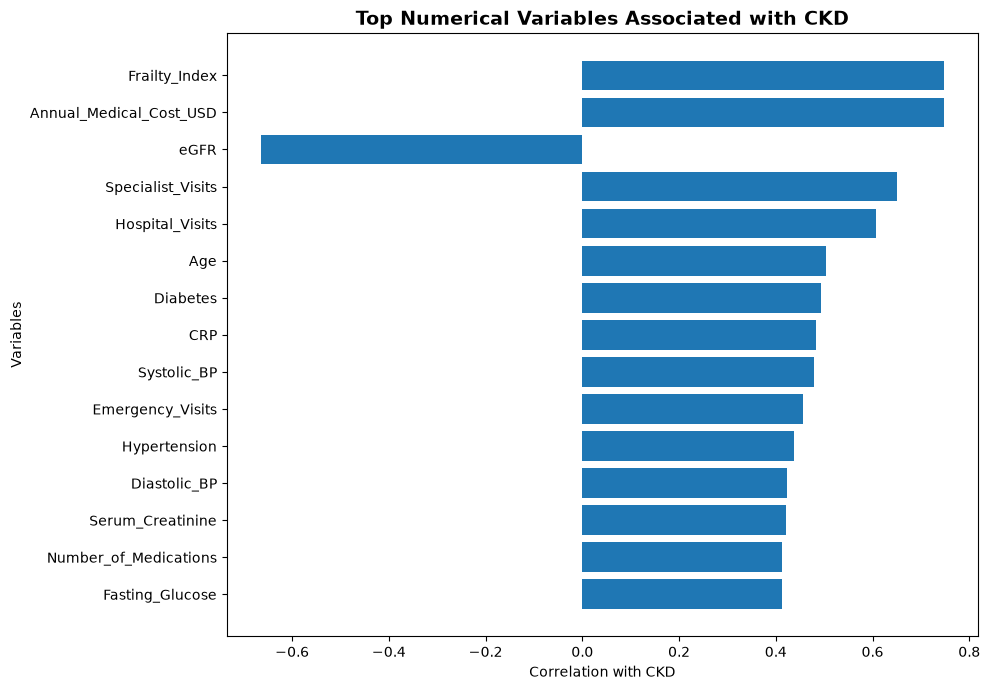


Visualization generated successfully.

-----------------------------------------------------------------------------


In [84]:
# =============================================================================
# STEP 28A : TOP NUMERICAL VARIABLES ASSOCIATED WITH CKD
# =============================================================================

import matplotlib.pyplot as plt

top_features = ckd_corr_df.head(15)

plt.figure(figsize=(10,7))

plt.barh(

    top_features["Variable"][::-1],

    top_features["Correlation with CKD"][::-1]

)

plt.title(

    "Top Numerical Variables Associated with CKD",

    fontsize=14,

    fontweight="bold"

)

plt.xlabel("Correlation with CKD")

plt.ylabel("Variables")

plt.tight_layout()

plt.show()

print("\nVisualization generated successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

               CATEGORICAL VARIABLES VS CKD


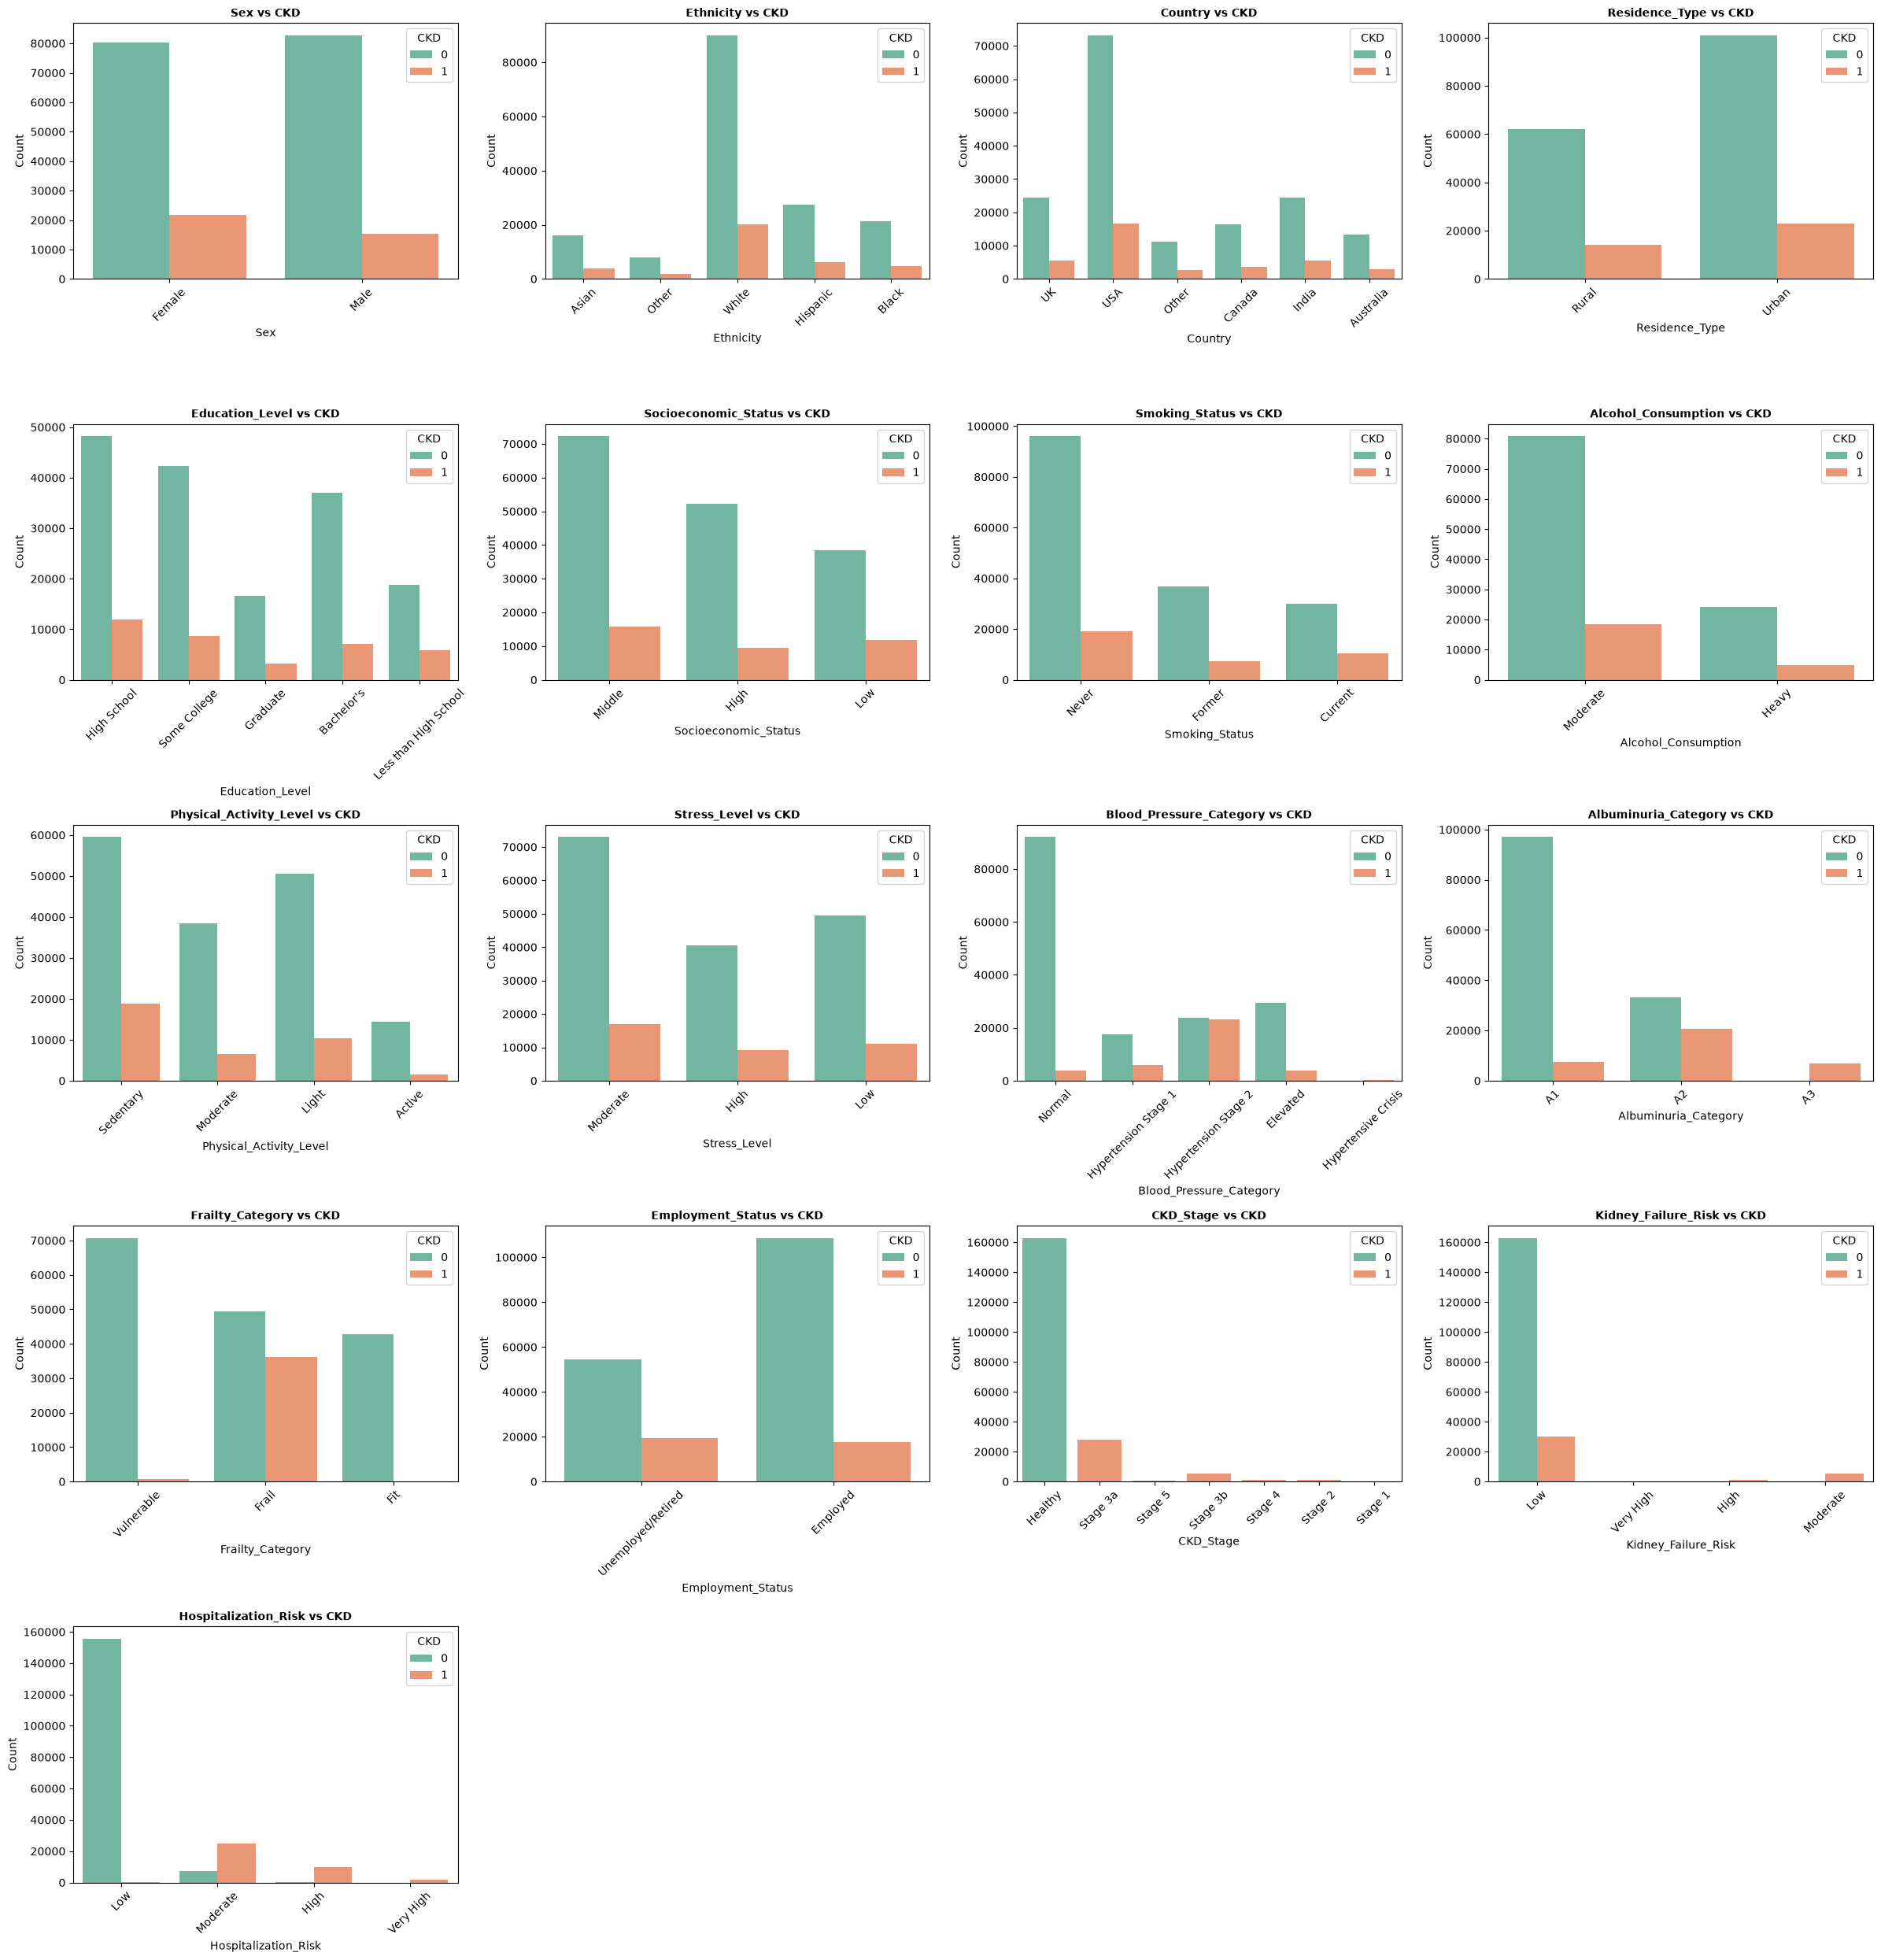


Categorical variable analysis completed.

-----------------------------------------------------------------------------


In [85]:
# =============================================================================
# STEP 29 : CATEGORICAL VARIABLES VS CKD
# =============================================================================
#
# Objective:
# Examine how categorical variables are distributed across CKD status.
# Display 4 plots per row.
#
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import math

target = "CKD"

categorical_analysis = [
    feature
    for feature in categorical_features
    if feature != target
]

print("="*90)
print("               CATEGORICAL VARIABLES VS CKD")
print("="*90)

# Number of columns per row
n_cols = 4

# Calculate required rows
n_rows = math.ceil(len(categorical_analysis) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(24, 5*n_rows)
)

# Convert axes to 1D array
axes = axes.flatten()

for i, feature in enumerate(categorical_analysis):

    sns.countplot(
        data=Data,
        x=feature,
        hue=target,
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} vs CKD",
        fontsize=10,
        fontweight="bold"
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\nCategorical variable analysis completed.")
print("\n" + "-"*77)

# -----------------------------------------------------------------------------

In [86]:
# =============================================================================
# STEP 30 : EDA SUMMARY REPORT
# =============================================================================

print("="*90)
print("                         EDA SUMMARY REPORT")
print("="*90)

print(f"Dataset Shape                 : {Data.shape}")

print(f"Numerical Variables           : {len(numerical_features)}")

print(f"Categorical Variables         : {len(categorical_features)}")

print(f"Missing Values                : {Data.isnull().sum().sum():,}")

print(f"Duplicate Records             : {Data.duplicated().sum():,}")

print(f"Continuous Variables          : {len(continuous_features)}")

print(f"Discrete Variables            : {len(discrete_features)}")

print(f"Binary Variables              : {len(binary_features)}")

print(f"Highly Correlated Pairs       : {len(high_corr)}")

print("\nEDA completed successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                         EDA SUMMARY REPORT
Dataset Shape                 : (200000, 81)
Numerical Variables           : 64
Categorical Variables         : 17
Missing Values                : 370,399
Duplicate Records             : 0
Continuous Variables          : 41
Discrete Variables            : 4
Binary Variables              : 19
Highly Correlated Pairs       : 11

EDA completed successfully.

-----------------------------------------------------------------------------


In [87]:
#STATISTICAL ANALYSIS
# =============================================================================
# STEP 31 : CHI-SQUARE TEST
# =============================================================================
#
# Objective:
# Determine whether categorical variables are significantly associated
# with CKD status.
#
# H0 : Variable and CKD are independent
# H1 : Variable and CKD are associated
#
# =============================================================================

from scipy.stats import chi2_contingency

chi_square_results = []

# Exclude target variable
categorical_test_features = [

    col

    for col in categorical_features

    if col != "CKD"

]

for feature in categorical_test_features:

    contingency_table = pd.crosstab(

        Data[feature],

        Data["CKD"]

    )

    chi2, p_value, dof, expected = chi2_contingency(

        contingency_table

    )

    chi_square_results.append([

        feature,

        chi2,

        p_value

    ])

# Create results dataframe
chi_square_results = pd.DataFrame(

    chi_square_results,

    columns=[

        "Variable",

        "Chi-Square Statistic",

        "P-Value"

    ]

)

# Sort by significance
chi_square_results = chi_square_results.sort_values(

    by="P-Value"

)

print("="*90)
print("                 CHI-SQUARE TEST RESULTS")
print("="*90)

display(chi_square_results)

print("\nChi-square testing completed successfully.")

print("\n" + "-"*77)
non_significant = chi_square_results[
    chi_square_results["P-Value"] >= 0.05
]

display(non_significant)
leakage_features = [

    "CKD_Stage",
    "Kidney_Failure_Risk",
    "Hospitalization_Risk",
    "Albuminuria_Category",
    "Frailty_Category"

]

print(leakage_features)
# -----------------------------------------------------------------------------

                 CHI-SQUARE TEST RESULTS


,Variable,Chi-Square Statistic,P-Value
6,Smoking_Status,1897.385283,0.000000e+00
15,Kidney_Failure_Risk,31268.888112,0.000000e+00
13,Employment_Status,4615.742582,0.000000e+00
14,CKD_Stage,200000.000000,0.000000e+00
12,Frailty_Category,56188.854329,0.000000e+00
11,Albuminuria_Category,47499.014836,0.000000e+00
10,Blood_Pressure_Category,45425.163564,0.000000e+00
8,Physical_Activity_Level,3129.729489,0.000000e+00
16,Hospitalization_Risk,158837.277639,0.000000e+00
5,Socioeconomic_Status,1335.496161,1.001598e-290



Chi-square testing completed successfully.

-----------------------------------------------------------------------------


,Variable,Chi-Square Statistic,P-Value
1,Ethnicity,8.004058,0.091430
3,Residence_Type,0.884877,0.346869
2,Country,1.057875,0.957764


['CKD_Stage', 'Kidney_Failure_Risk', 'Hospitalization_Risk', 'Albuminuria_Category', 'Frailty_Category']


In [88]:
# =============================================================================
# STEP 32 : CRAMER'S V ANALYSIS
# =============================================================================

import numpy as np

cramers_results = []

for feature in categorical_features:

    if feature != "CKD":

        contingency = pd.crosstab(

            Data[feature],
            Data["CKD"]

        )

        chi2 = chi2_contingency(contingency)[0]

        n = contingency.sum().sum()

        r, k = contingency.shape

        cramers_v = np.sqrt(

            chi2 / (n * (min(r, k) - 1))

        )

        cramers_results.append([

            feature,
            cramers_v

        ])

cramers_results = pd.DataFrame(

    cramers_results,

    columns=[

        "Variable",
        "Cramers_V"

    ]

)

cramers_results = cramers_results.sort_values(

    by="Cramers_V",
    ascending=False

)

display(cramers_results)

,Variable,Cramers_V
14,CKD_Stage,1.000000
16,Hospitalization_Risk,0.891171
11,Albuminuria_Category,0.536474
12,Frailty_Category,0.530042
10,Blood_Pressure_Category,0.476577
15,Kidney_Failure_Risk,0.395404
13,Employment_Status,0.151917
8,Physical_Activity_Level,0.125095
6,Smoking_Status,0.097401
5,Socioeconomic_Status,0.081716


In [89]:
# =============================================================================
# STEP 33 : MANN-WHITNEY U TEST
# =============================================================================
#
# Objective:
# Compare numerical variables between CKD and Non-CKD groups.
#
# H0 : Distribution of the variable is the same across CKD groups
# H1 : Distribution differs significantly between CKD groups
#
# =============================================================================

from scipy.stats import mannwhitneyu

mw_results = []

# Exclude target variable
numerical_test_features = [

    col

    for col in numerical_features

    if col != "CKD"

]

for feature in numerical_test_features:

    group_0 = Data.loc[
        Data["CKD"] == 0,
        feature
    ].dropna()

    group_1 = Data.loc[
        Data["CKD"] == 1,
        feature
    ].dropna()

    try:

        statistic, p_value = mannwhitneyu(
            group_0,
            group_1,
            alternative="two-sided"
        )

        mw_results.append([

            feature,

            statistic,

            p_value

        ])

    except:

        pass

# Create DataFrame
mw_results = pd.DataFrame(

    mw_results,

    columns=[

        "Variable",

        "Mann-Whitney Statistic",

        "P-Value"

    ]

)

# Sort by significance
mw_results = mw_results.sort_values(

    by="P-Value"

)

print("="*90)
print("                    MANN-WHITNEY U TEST RESULTS")
print("="*90)

display(mw_results.head(30))

print("\nStatistical testing completed successfully.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                    MANN-WHITNEY U TEST RESULTS


,Variable,Mann-Whitney Statistic,P-Value
0,Age,8.700923e+08,0.0
2,Weight_kg,2.264734e+09,0.0
3,BMI,2.023385e+09,0.0
4,Waist_Circumference_cm,1.827695e+09,0.0
6,Exercise_Hours_Per_Week,3.542431e+09,0.0
5,Body_Fat_Percentage,1.040948e+09,0.0
7,Daily_Steps,3.547261e+09,0.0
15,Heart_Failure,2.906824e+09,0.0
13,Hypertension,1.413565e+09,0.0
14,Cardiovascular_Disease,2.363589e+09,0.0



Statistical testing completed successfully.

-----------------------------------------------------------------------------


In [90]:
# #Statistical Analysis
#     |
#     ├── Descriptive Statistics
#     ├── Mann-Whitney U Test
#     ├── Cramer's V Analysis
#     ├── Correlation Analysis
#     └── Feature Screening

# Feature Engineering
#     |
#     ├── Create Severity Classes
#     ├── Encode Severity Target
#     ├── Remove Leakage Features
#     ├── Missing Value Treatment
#     ├── One-Hot Encoding
#     ├── Feature Scaling
#     └── SMOTE

# Model Development
#     |
#     ├── Ordinal Logistic Regression
#     ├── Random Forest
#     └── XGBoost

# Model Evaluation
#     |
#     ├── Accuracy
#     ├── Macro Precision
#     ├── Macro Recall
#     ├── Macro F1
#     ├── QWK
#     ├── Confusion Matrix
#     └── Feature Importance

In [91]:
# =============================================================================
# STEP 34 : SIGNIFICANT NUMERICAL VARIABLES
# =============================================================================

significant_numerical = mw_results[

    mw_results["P-Value"] < 0.05

]

print("="*90)
print("                SIGNIFICANT NUMERICAL VARIABLES")
print("="*90)

print(f"Number of Significant Variables : {len(significant_numerical)}")

display(significant_numerical)

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                SIGNIFICANT NUMERICAL VARIABLES
Number of Significant Variables : 58


,Variable,Mann-Whitney Statistic,P-Value
0,Age,8.700923e+08,0.000000e+00
2,Weight_kg,2.264734e+09,0.000000e+00
3,BMI,2.023385e+09,0.000000e+00
4,Waist_Circumference_cm,1.827695e+09,0.000000e+00
6,Exercise_Hours_Per_Week,3.542431e+09,0.000000e+00
5,Body_Fat_Percentage,1.040948e+09,0.000000e+00
7,Daily_Steps,3.547261e+09,0.000000e+00
15,Heart_Failure,2.906824e+09,0.000000e+00
13,Hypertension,1.413565e+09,0.000000e+00
14,Cardiovascular_Disease,2.363589e+09,0.000000e+00



-----------------------------------------------------------------------------


In [92]:
# =============================================================================
# STEP 35 : PRELIMINARY FEATURE SCREENING
# =============================================================================

weak_features = [

    "Country",
    "Residence_Type",
    "Ethnicity",
    "Stress_Level",
    "Alcohol_Consumption"

]

leakage_features = [

    "CKD_Stage",
    "Kidney_Failure_Risk",
    "Hospitalization_Risk"

]

print("="*90)
print("                 FEATURE SCREENING SUMMARY")
print("="*90)

print("\nWeak Features")

for feature in weak_features:
    print(feature)

print("\nPotential Leakage Features")

for feature in leakage_features:
    print(feature)

print("\nReview before preprocessing.")

print("\n" + "-"*77)

                 FEATURE SCREENING SUMMARY

Weak Features
Country
Residence_Type
Ethnicity
Stress_Level
Alcohol_Consumption

Potential Leakage Features
CKD_Stage
Kidney_Failure_Risk
Hospitalization_Risk

Review before preprocessing.

-----------------------------------------------------------------------------


In [93]:
# =============================================================================
# STEP 36 : FINAL FEATURE REVIEW
# =============================================================================

weak_features = [

    "Country",
    "Residence_Type",
    "Ethnicity",
    "Stress_Level",
    "Alcohol_Consumption"

]

leakage_features = [

    "CKD_Stage",
    "Kidney_Failure_Risk",
    "Hospitalization_Risk",
    "Dialysis_Required"

]

print("="*90)
print("                  FEATURE REVIEW SUMMARY")
print("="*90)

print("\nWeak Features")

for feature in weak_features:
    print(f"- {feature}")

print("\nPotential Leakage Features")

for feature in leakage_features:
    print(f"- {feature}")

print("\nReview completed.")

print("\n" + "-"*77)

# -----------------------------------------------------------------------------

                  FEATURE REVIEW SUMMARY

Weak Features
- Country
- Residence_Type
- Ethnicity
- Stress_Level
- Alcohol_Consumption

Potential Leakage Features
- CKD_Stage
- Kidney_Failure_Risk
- Hospitalization_Risk
- Dialysis_Required

Review completed.

-----------------------------------------------------------------------------


In [94]:
# # =============================================================================
# # STEP 39 : TRAIN-TEST SPLIT FOR CKD SEVERITY MODEL
# # =============================================================================
# #
# # Objective:
# # Predict CKD Severity
# #
# # Classes:
# # 0 = Healthy
# # 1 = Mild CKD
# # 2 = Moderate CKD
# # 3 = Severe CKD
# #
# # Stratified sampling ensures all severity classes
# # are represented proportionally in both train and test sets.
# # =============================================================================

# from sklearn.model_selection import train_test_split

# # -------------------------------------------------------------------------
# # Features
# # -------------------------------------------------------------------------

# X = X_severity

# # -------------------------------------------------------------------------
# # Target
# # -------------------------------------------------------------------------

# y = y_severity

# # -------------------------------------------------------------------------
# # Train-Test Split
# # -------------------------------------------------------------------------

# X_train, X_test, y_train, y_test = train_test_split(

#     X,

#     y,

#     test_size=0.20,

#     random_state=42,

#     stratify=y

# )

# # -------------------------------------------------------------------------
# # Verify Shapes
# # -------------------------------------------------------------------------

# print("X_train Shape :", X_train.shape)
# print("X_test Shape  :", X_test.shape)

# print("y_train Shape :", y_train.shape)
# print("y_test Shape  :", y_test.shape)

# # -------------------------------------------------------------------------
# # Verify Class Distribution
# # -------------------------------------------------------------------------

# print("\nTraining Class Distribution")
# print(y_train.value_counts().sort_index())

# print("\nTesting Class Distribution")
# print(y_test.value_counts().sort_index())

In [95]:
# =============================================================================
# CREATE SEVERITY CLASS FROM CKD STAGE
# =============================================================================

Data['Severity_Class'] = Data['CKD_Stage'].replace({
    'Healthy': 'Healthy',
    'Stage 1': 'Mild CKD',
    'Stage 2': 'Mild CKD',
    'Stage 3a': 'Moderate CKD',
    'Stage 3b': 'Moderate CKD',
    'Stage 4': 'Severe CKD',
    'Stage 5': 'Severe CKD'
})

print(Data['Severity_Class'].value_counts())
# =============================================================================
# STEP 44 : CREATE SEVERITY TARGET
# =============================================================================

severity_mapping = {
    'Healthy': 0,
    'Mild CKD': 1,
    'Moderate CKD': 2,
    'Severe CKD': 3
}

Data['Severity_Encoded'] = Data['Severity_Class'].map(
    severity_mapping
)

y_severity = Data['Severity_Encoded']

print(y_severity.value_counts().sort_index())

Severity_Class
Healthy         162948
Moderate CKD     33751
Severe CKD        2203
Mild CKD          1098
Name: count, dtype: int64
Severity_Encoded
0    162948
1      1098
2     33751
3      2203
Name: count, dtype: int64


In [96]:
# =============================================================================
# STEP 45 : CREATE FEATURES FOR SEVERITY MODEL
# =============================================================================

severity_drop = [
    'CKD',
    'CKD_Stage',
    'Severity_Class',
    'Severity_Encoded',
    'Kidney_Failure_Risk',
    'Hospitalization_Risk',
    'Albuminuria_Category',
    'Dialysis_Required'
]

X_severity = Data.drop(
    columns=severity_drop,
    errors='ignore'
)

print(X_severity.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_severity,
    y_severity,
    test_size=0.20,
    random_state=42,
    stratify=y_severity
)

print(X_train.shape)
print(X_test.shape)

# =============================================================================
# VERIFY FEATURES USED FOR CKD SEVERITY MODEL
# =============================================================================

print("Number of Features:", len(X_severity.columns))

print("\nFeature Names:\n")

for col in X_severity.columns:
    print(col)

(200000, 75)


(160000, 75)
(40000, 75)
Number of Features: 75

Feature Names:

Age
Sex
Ethnicity
Country
Residence_Type
Education_Level
Socioeconomic_Status
Height_cm
Weight_kg
BMI
Waist_Circumference_cm
Body_Fat_Percentage
Smoking_Status
Alcohol_Consumption
Physical_Activity_Level
Exercise_Hours_Per_Week
Daily_Steps
Water_Intake_L
Sodium_Intake_mg
Fast_Food_Frequency_Per_Week
Sleep_Duration_Hours
Stress_Level
Diabetes
Hypertension
Cardiovascular_Disease
Heart_Failure
Hyperlipidemia
Kidney_Stones
Recurrent_UTI
Autoimmune_Disease
Family_History_CKD
Obesity
Heart_Rate
Respiratory_Rate
Oxygen_Saturation
Systolic_BP
Diastolic_BP
Blood_Pressure_Category
Serum_Creatinine
eGFR
Blood_Urea_Nitrogen
Albumin
Urine_ACR
Urine_Protein
HbA1c
Fasting_Glucose
Hemoglobin
Sodium
Potassium
Calcium
Phosphorus
Uric_Acid
Total_Cholesterol
HDL
LDL
Triglycerides
CRP
ACE_Inhibitor
ARB
Diabetes_Medication
Statin
Diuretic
NSAID_Usage
Medication_Adherence
Number_of_Medications
Frailty_Index
Frailty_Category
Hospital_Visits
Eme

In [97]:
# =============================================================================
# STEP 46 : CHECK SEVERITY CLASS DISTRIBUTION
# =============================================================================
# Purpose:
# Check imbalance before applying SMOTE.
# =============================================================================

print("Training Class Distribution")

print(
    y_train.value_counts().sort_index()
)

print("\nPercentage Distribution")

print(
    round(
        y_train.value_counts(normalize=True).sort_index()*100,
        2
    )
)

Training Class Distribution
Severity_Encoded
0    130359
1       878
2     27001
3      1762
Name: count, dtype: int64

Percentage Distribution
Severity_Encoded
0    81.47
1     0.55
2    16.88
3     1.10
Name: proportion, dtype: float64


In [98]:
# =============================================================================
# STEP 47 : SEPARATE NUMERICAL AND CATEGORICAL FEATURES
# =============================================================================

import numpy as np

num_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Features :", len(num_cols))
print("Categorical Features :", len(cat_cols))

print("\nCategorical Columns")

print(cat_cols)

Numerical Features : 62
Categorical Features : 13

Categorical Columns
['Sex', 'Ethnicity', 'Country', 'Residence_Type', 'Education_Level', 'Socioeconomic_Status', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Stress_Level', 'Blood_Pressure_Category', 'Frailty_Category', 'Employment_Status']


In [99]:
# =============================================================================
# STEP 48 : HANDLE MISSING VALUES
# =============================================================================

from sklearn.impute import SimpleImputer

# -----------------------------
# Numerical Variables
# -----------------------------

num_imputer = SimpleImputer(
    strategy="median"
)

X_train[num_cols] = num_imputer.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = num_imputer.transform(
    X_test[num_cols]
)

# -----------------------------
# Categorical Variables
# -----------------------------

if len(cat_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    X_train[cat_cols] = cat_imputer.fit_transform(
        X_train[cat_cols]
    )

    X_test[cat_cols] = cat_imputer.transform(
        X_test[cat_cols]
    )

print("Missing Values Removed")

print(
    X_train.isnull().sum().sum()
)

print(
    X_test.isnull().sum().sum()
)

Missing Values Removed
0
0


In [100]:
# =============================================================================
# STEP 49 : MISSING VALUE IMPUTATION
# =============================================================================

from sklearn.impute import SimpleImputer

# Numerical Variables

num_imputer = SimpleImputer(strategy="median")

X_train[num_cols] = num_imputer.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = num_imputer.transform(
    X_test[num_cols]
)

# Categorical Variables

if len(cat_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    X_train[cat_cols] = cat_imputer.fit_transform(
        X_train[cat_cols]
    )

    X_test[cat_cols] = cat_imputer.transform(
        X_test[cat_cols]
    )

print("Missing Values Removed")

print(X_train.shape)
print(X_test.shape)


Missing Values Removed
(160000, 75)
(40000, 75)


In [101]:
# =============================================================================
# STEP 49 : ONE-HOT ENCODING
# =============================================================================

import pandas as pd

X_train = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True
)

# Make train/test identical

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoding Completed")

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Encoding Completed
Train Shape : (160000, 94)
Test Shape  : (40000, 94)


In [102]:
# =============================================================================
# STEP 50 : FEATURE SCALING
# =============================================================================
# Required for:
# Ordinal Logistic Regression
# rFM
# XGBoost
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling Completed")

print(X_train_scaled.shape)
print(X_test_scaled.shape)

Scaling Completed
(160000, 94)
(40000, 94)


In [103]:
# =============================================================================
# STEP 54 : APPLY SMOTE FOR CKD SEVERITY BALANCING
# =============================================================================
#
# Objective:
# Handle severe class imbalance in CKD severity classes.
#
# Severity Classes:
# 0 = Healthy
# 1 = Mild CKD
# 2 = Moderate CKD
# 3 = Severe CKD
#
# Why SMOTE?
# - Mild CKD and Severe CKD are heavily underrepresented.
# - Models tend to favor the majority class (Healthy).
# - SMOTE creates synthetic samples for minority classes.
# - Improves learning of rare CKD severity stages.
#
# IMPORTANT:
# ✓ Apply SMOTE ONLY on training data
# ✓ Never apply SMOTE on test data
# ✓ Test data must remain untouched for fair evaluation
#
# Input:
# X_train_scaled
# y_train
#
# Output:
# X_train_smote
# y_train_smote
#
# =============================================================================

from imblearn.over_sampling import SMOTE
import pandas as pd

# Create SMOTE object
smote = SMOTE(
    sampling_strategy='auto',   # Balance all classes
    k_neighbors=3,              # Suitable for small minority classes
    random_state=42
)

# Apply SMOTE ONLY on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# =============================================================================
# CHECK CLASS DISTRIBUTION BEFORE SMOTE
# =============================================================================

print("="*70)
print("CLASS DISTRIBUTION BEFORE SMOTE")
print("="*70)

print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

# =============================================================================
# CHECK CLASS DISTRIBUTION AFTER SMOTE
# =============================================================================

print("\n")

print("="*70)
print("CLASS DISTRIBUTION AFTER SMOTE")
print("="*70)

print(
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

# =============================================================================
# VERIFY SHAPES
# =============================================================================

print("\n")

print("="*70)
print("SHAPE AFTER SMOTE")
print("="*70)

print("X_train_smote :", X_train_smote.shape)
print("y_train_smote :", y_train_smote.shape)

CLASS DISTRIBUTION BEFORE SMOTE
Severity_Encoded
0    130359
1       878
2     27001
3      1762
Name: count, dtype: int64


CLASS DISTRIBUTION AFTER SMOTE
Severity_Encoded
0    130359
1    130359
2    130359
3    130359
Name: count, dtype: int64


SHAPE AFTER SMOTE
X_train_smote : (521436, 94)
y_train_smote : (521436,)


In [104]:
# =============================================================================
# STEP 55 : TRAIN MODELS ON SMOTE DATA
# =============================================================================

# =============================================================================
# STEP : RANDOM FOREST ON SMOTE DATA
# =============================================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest Trained Successfully")



Random Forest Trained Successfully


In [105]:
# =============================================================================
# STEP : XGBOOST ON SMOTE DATA
# =============================================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost Trained Successfully")

XGBoost Trained Successfully


In [106]:
# =============================================================================
# STEP : ORDINAL LOGISTIC REGRESSION ON SMOTE DATA
# =============================================================================

from mord import LogisticIT

ordinal_model = LogisticIT()

ordinal_model.fit(
    X_train_smote,
    y_train_smote
)

print("Ordinal Logistic Regression Trained Successfully")

C:\Users\SAMSUNG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',


Ordinal Logistic Regression Trained Successfully


In [107]:
# =============================================================================
# STEP : EVALUATE SMOTE ORDINAL LOGISTIC REGRESSION
# =============================================================================
#
# IMPORTANT:
# Model is trained on SMOTE-balanced training data
# Evaluation must be performed on ORIGINAL TEST DATA
#
# X_test_scaled  -> Original test features
# y_test         -> Original test labels
#
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    cohen_kappa_score
)

# Generate predictions on ORIGINAL test set
ord_pred = ordinal_model.predict(X_test_scaled)

print("Predictions Generated Successfully")

# =============================================================================
# PERFORMANCE METRICS
# =============================================================================

accuracy = accuracy_score(y_test, ord_pred)

precision = precision_score(
    y_test,
    ord_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    ord_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    ord_pred,
    average='weighted'
)

qwk = cohen_kappa_score(
    y_test,
    ord_pred,
    weights='quadratic'
)

print("="*70)
print("SMOTE ORDINAL LOGISTIC REGRESSION PERFORMANCE")
print("="*70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"QWK      : {qwk:.4f}")

# =============================================================================
# MACRO METRICS
# =============================================================================

macro_precision = precision_score(
    y_test,
    ord_pred,
    average='macro'
)

macro_recall = recall_score(
    y_test,
    ord_pred,
    average='macro'
)

macro_f1 = f1_score(
    y_test,
    ord_pred,
    average='macro'
)

print("="*70)
print("SMOTE ORDINAL LOGISTIC MACRO METRICS")
print("="*70)

print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    ord_pred
)

print("="*70)
print("SMOTE ORDINAL LOGISTIC CONFUSION MATRIX")
print("="*70)

print(cm)

Predictions Generated Successfully
SMOTE ORDINAL LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.9227
Precision: 0.9921
Recall   : 0.9227
F1 Score : 0.9543
QWK      : 0.9383
SMOTE ORDINAL LOGISTIC MACRO METRICS
Macro Precision : 0.7411
Macro Recall    : 0.8859
Macro F1        : 0.7372
SMOTE ORDINAL LOGISTIC CONFUSION MATRIX
[[30334  2254     1     0]
 [   26   163    31     0]
 [    1   733  5978    38]
 [    0     0     6   435]]


In [108]:
# =============================================================================
# RANDOM FOREST PERFORMANCE METRICS
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

# Basic Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted'
)

# Ordinal Metric
rf_qwk = cohen_kappa_score(
    y_test,
    rf_pred,
    weights='quadratic'
)

# Macro Metrics
rf_macro_precision = precision_score(
    y_test,
    rf_pred,
    average='macro'
)

rf_macro_recall = recall_score(
    y_test,
    rf_pred,
    average='macro'
)

rf_macro_f1 = f1_score(
    y_test,
    rf_pred,
    average='macro'
)

print("="*70)
print("RANDOM FOREST PERFORMANCE")
print("="*70)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))
print("QWK      :", round(rf_qwk,4))

print("="*70)
print("RANDOM FOREST MACRO METRICS")
print("="*70)

print("Macro Precision :", round(rf_macro_precision,4))
print("Macro Recall    :", round(rf_macro_recall,4))
print("Macro F1        :", round(rf_macro_f1,4))

print("="*70)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("="*70)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "Healthy",
            "Mild CKD",
            "Moderate CKD",
            "Severe CKD"
        ]
    )
)

print("="*70)
print("RANDOM FOREST CONFUSION MATRIX")
print("="*70)

print(
    confusion_matrix(
        y_test,
        rf_pred
    )
)

RANDOM FOREST PERFORMANCE
Accuracy : 0.9981
Precision: 0.9981
Recall   : 0.9981
F1 Score : 0.998
QWK      : 0.9986
RANDOM FOREST MACRO METRICS
Macro Precision : 0.9846
Macro Recall    : 0.9289
Macro F1        : 0.9532
RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     32589
    Mild CKD       0.94      0.72      0.82       220
Moderate CKD       1.00      1.00      1.00      6750
  Severe CKD       1.00      0.99      1.00       441

    accuracy                           1.00     40000
   macro avg       0.98      0.93      0.95     40000
weighted avg       1.00      1.00      1.00     40000

RANDOM FOREST CONFUSION MATRIX
[[32579    10     0     0]
 [   61   159     0     0]
 [    0     0  6750     0]
 [    0     0     3   438]]


XGBOOST PERFORMANCE
Accuracy : 0.9985
Precision: 0.9985
Recall   : 0.9985
F1 Score : 0.9985
QWK      : 0.9984
XGBOOST MACRO METRICS
Macro Precision : 0.9848
Macro Recall    : 0.9557
Macro F1        : 0.9692
XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     32589
    Mild CKD       0.95      0.83      0.88       220
Moderate CKD       1.00      1.00      1.00      6750
  Severe CKD       0.99      1.00      1.00       441

    accuracy                           1.00     40000
   macro avg       0.98      0.96      0.97     40000
weighted avg       1.00      1.00      1.00     40000

XGBOOST CONFUSION MATRIX
[[32582     6     1     0]
 [   36   182     2     0]
 [    7     4  6736     3]
 [    0     0     1   440]]


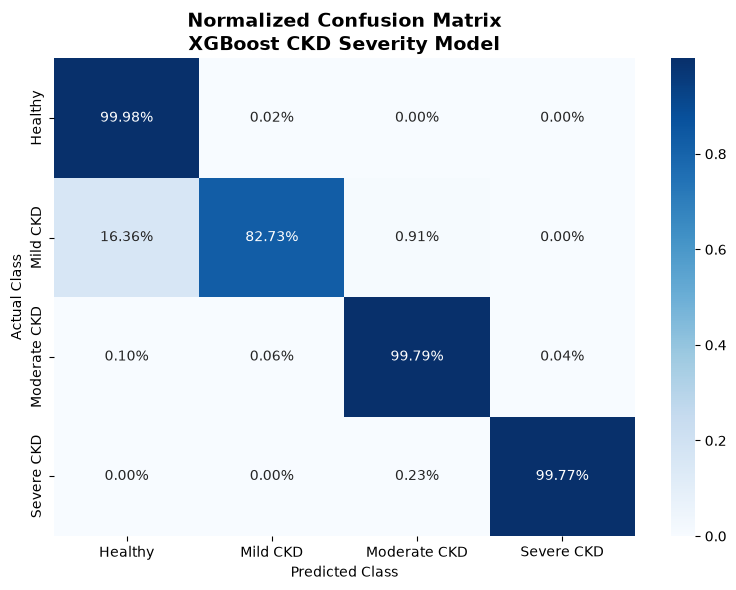

In [109]:
# =============================================================================
# XGBOOST PERFORMANCE METRICS
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)

# Predictions
xgb_pred = xgb_model.predict(X_test_scaled)

# Basic Metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average='weighted'
)

# QWK
xgb_qwk = cohen_kappa_score(
    y_test,
    xgb_pred,
    weights='quadratic'
)

# Macro Metrics
xgb_macro_precision = precision_score(
    y_test,
    xgb_pred,
    average='macro'
)

xgb_macro_recall = recall_score(
    y_test,
    xgb_pred,
    average='macro'
)

xgb_macro_f1 = f1_score(
    y_test,
    xgb_pred,
    average='macro'
)

print("="*70)
print("XGBOOST PERFORMANCE")
print("="*70)

print("Accuracy :", round(xgb_accuracy,4))
print("Precision:", round(xgb_precision,4))
print("Recall   :", round(xgb_recall,4))
print("F1 Score :", round(xgb_f1,4))
print("QWK      :", round(xgb_qwk,4))

print("="*70)
print("XGBOOST MACRO METRICS")
print("="*70)

print("Macro Precision :", round(xgb_macro_precision,4))
print("Macro Recall    :", round(xgb_macro_recall,4))
print("Macro F1        :", round(xgb_macro_f1,4))

print("="*70)
print("XGBOOST CLASSIFICATION REPORT")
print("="*70)

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Healthy",
            "Mild CKD",
            "Moderate CKD",
            "Severe CKD"
        ]
    )
)

print("="*70)
print("XGBOOST CONFUSION MATRIX")
print("="*70)

print(
    confusion_matrix(
        y_test,
        xgb_pred
    )
)

# =============================================================================
# NORMALIZED CONFUSION MATRIX - XGBOOST CKD SEVERITY MODEL
# =============================================================================
#
# Purpose:
# - Shows percentage of correctly and incorrectly classified samples.
# - More informative than raw confusion matrix counts.
# - Helps identify which CKD severity classes are confused.
#
# Interpretation:
# - Diagonal values = Correct predictions
# - Off-diagonal values = Misclassifications
# - Higher diagonal percentages indicate better performance
#
# =============================================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    xgb_pred
)

# Convert counts into row-wise percentages
cm_percent = (
    cm.astype('float')
    / cm.sum(axis=1)[:, np.newaxis]
)

# Plot normalized confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=[
        "Healthy",
        "Mild CKD",
        "Moderate CKD",
        "Severe CKD"
    ],
    yticklabels=[
        "Healthy",
        "Mild CKD",
        "Moderate CKD",
        "Severe CKD"
    ]
)

plt.title(
    "Normalized Confusion Matrix\nXGBoost CKD Severity Model",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

                                 Feature  Importance
28                                  eGFR    0.371882
61               Annual_Medical_Cost_USD    0.290273
91                Frailty_Category_Frail    0.143191
31                             Urine_ACR    0.021105
57                     Specialist_Visits    0.019591
32                         Urine_Protein    0.017908
46                         ACE_Inhibitor    0.010669
92           Frailty_Category_Vulnerable    0.009975
78           Socioeconomic_Status_Middle    0.008857
56                      Emergency_Visits    0.006801
93  Employment_Status_Unemployed/Retired    0.006272
54                         Frailty_Index    0.005889
83      Physical_Activity_Level_Moderate    0.005725
21                               Obesity    0.005530
14                Cardiovascular_Disease    0.005474
84     Physical_Activity_Level_Sedentary    0.005062
65                       Ethnicity_Other    0.004573
58                       Annual_Checkups    0.

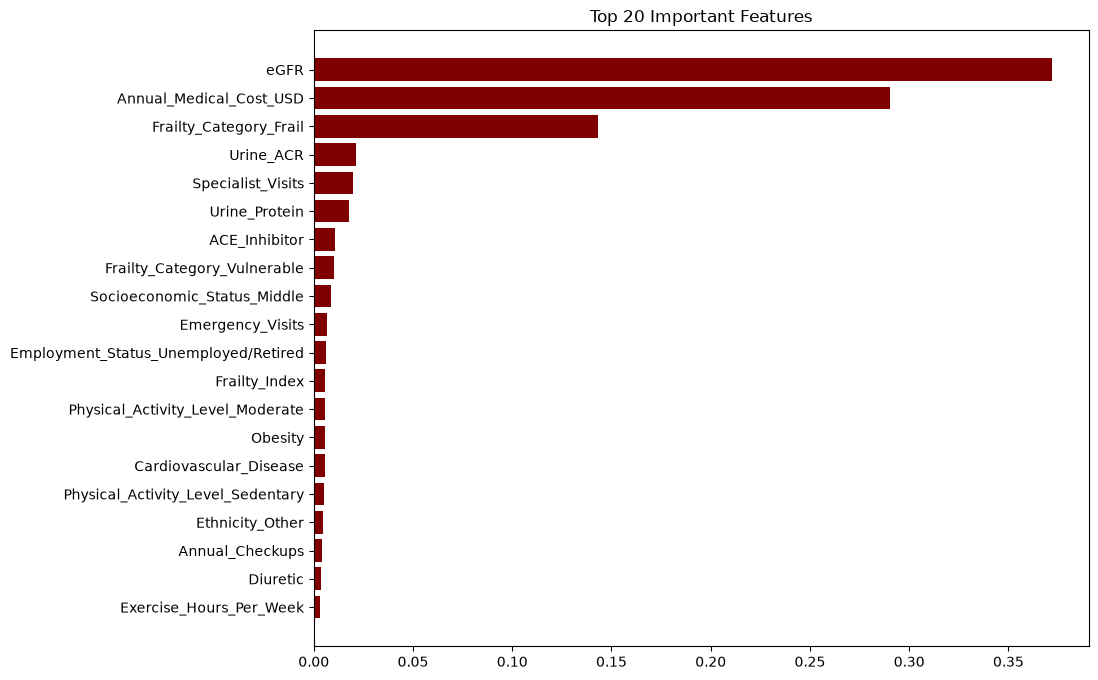

                                 Feature  Importance
28                                  eGFR    0.371882
61               Annual_Medical_Cost_USD    0.290273
91                Frailty_Category_Frail    0.143191
31                             Urine_ACR    0.021105
57                     Specialist_Visits    0.019591
32                         Urine_Protein    0.017908
46                         ACE_Inhibitor    0.010669
92           Frailty_Category_Vulnerable    0.009975
78           Socioeconomic_Status_Middle    0.008857
56                      Emergency_Visits    0.006801
93  Employment_Status_Unemployed/Retired    0.006272
54                         Frailty_Index    0.005889
83      Physical_Activity_Level_Moderate    0.005725
21                               Obesity    0.005530
14                Cardiovascular_Disease    0.005474
84     Physical_Activity_Level_Sedentary    0.005062
65                       Ethnicity_Other    0.004573
58                       Annual_Checkups    0.

In [134]:
# =============================================================================
# FEATURE IMPORTANCE - XGBOOST
# =============================================================================

import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

# ===========FEATURE IMPORTANCE PLOT==============
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'],
    top20['Importance'],
    color='maroon'
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()
# --------------FEATURE LEAKAGE AUDIT----------------
print(feature_importance.head(20))

In [111]:
#============CROSS VALIDATION FOR MODEL STABILITY==============

from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    xgb_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

print(scores)

print("Mean CV Score :", np.mean(scores))
print("Std CV Score  :", np.std(scores))

[0.9982644  0.9999137  0.99983698 0.99993288 0.99989452]
Mean CV Score : 0.9995684965136048
Std CV Score  : 0.0006528353370828046


SHAP values generated successfully


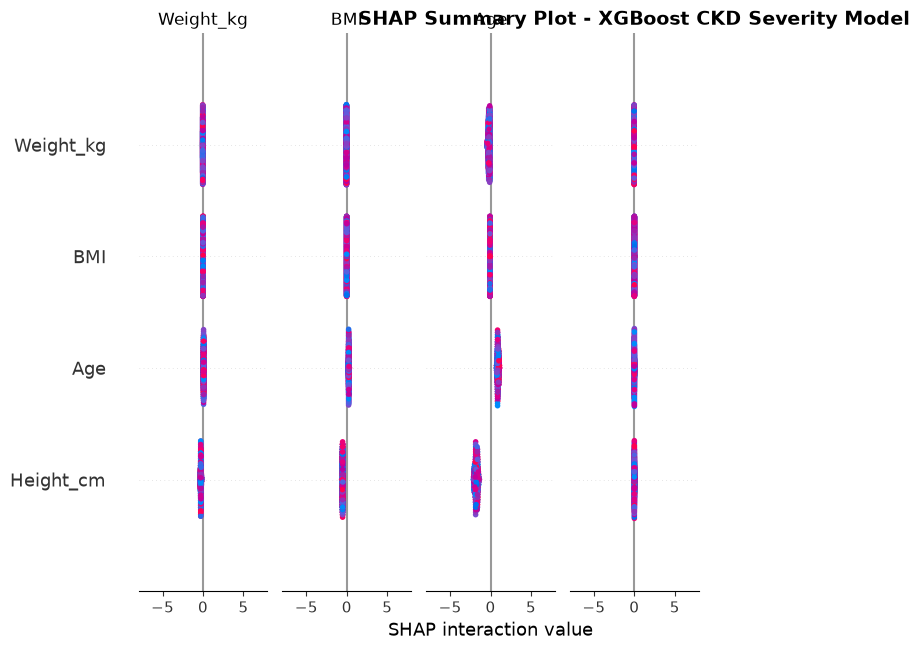

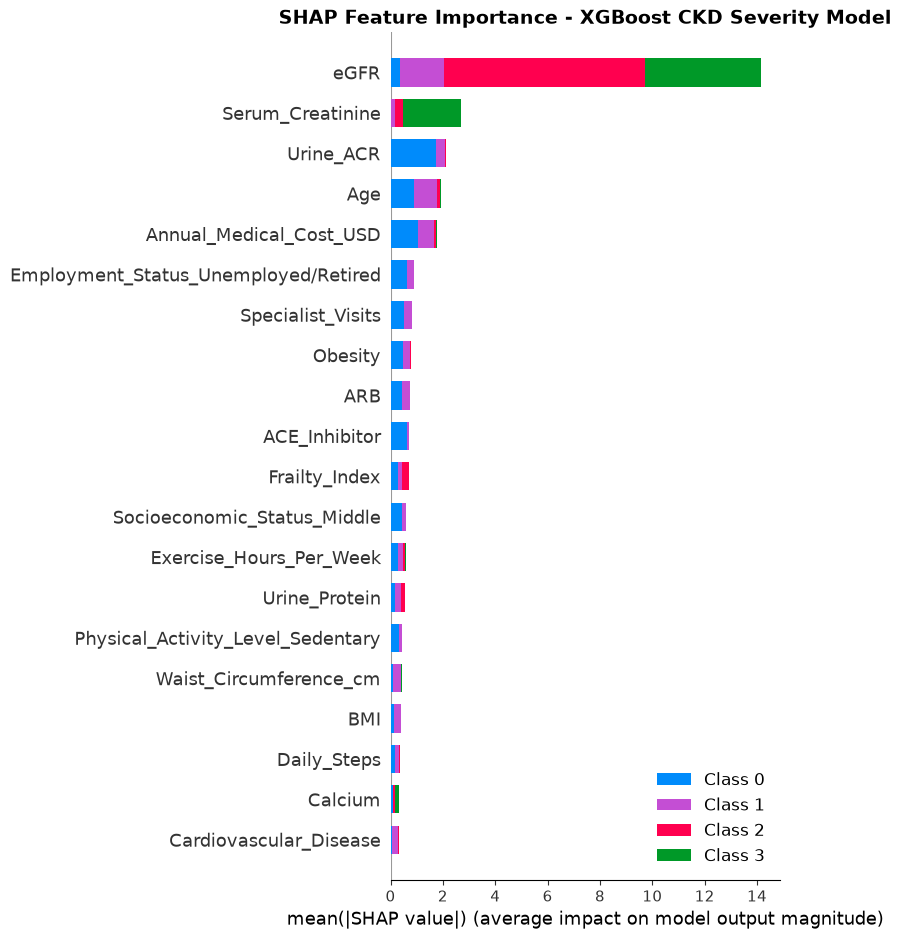

<class 'numpy.ndarray'>
Shape: (1000, 94, 4)


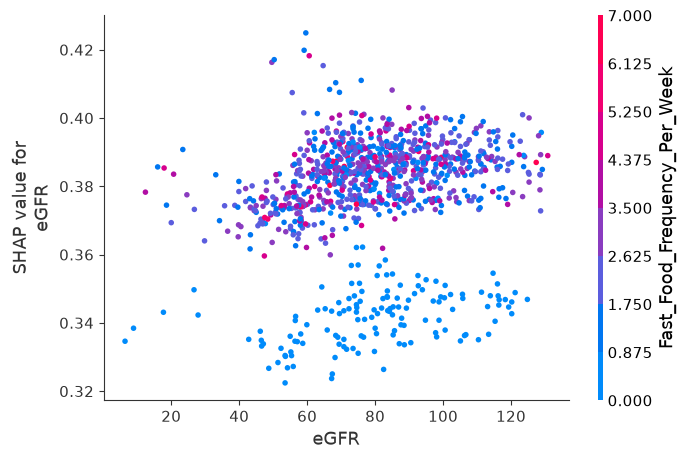

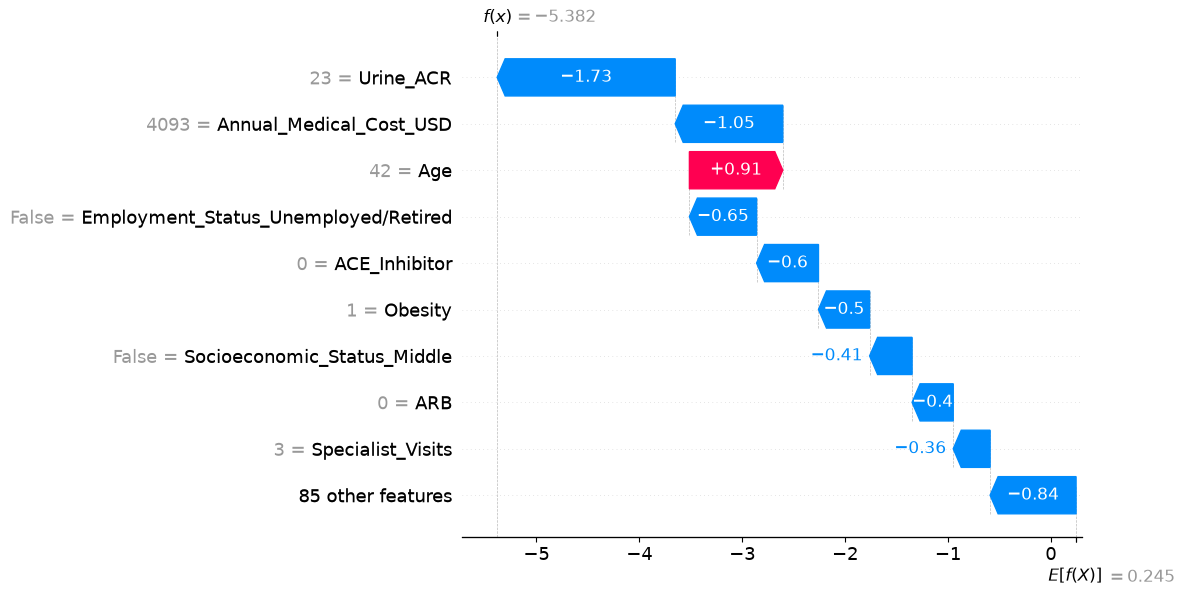

In [116]:
# =============================================================================
# SHAP EXPLAINABILITY FOR XGBOOST
# =============================================================================

import shap
import pandas as pd

explainer = shap.TreeExplainer(xgb_model)

# Use a sample to reduce computation time
X_sample = X_test.sample(
    n=1000,
    random_state=42
)

shap_values = explainer.shap_values(X_sample)

print("SHAP values generated successfully")

# =============================================================================
# SHAP SUMMARY PLOT
# =============================================================================

import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.title(
    "SHAP Summary Plot - XGBoost CKD Severity Model",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# =============================================================================
# SHAP FEATURE IMPORTANCE BAR PLOT
# =============================================================================

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Feature Importance - XGBoost CKD Severity Model",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape of first class:", shap_values[0].shape)
else:
    print("Shape:", shap_values.shape)


# =============================================================================
# SHAP DEPENDENCE PLOT
# =============================================================================

class_index = 0   # Change to 1, 2, or 3 for other CKD classes

shap.dependence_plot(
    "eGFR",
    shap_values[:, :, class_index],
    X_sample
)

# =============================================================================
# SHAP WATERFALL PLOT (Single Patient)
# =============================================================================

class_index = 0

explanation = shap.Explanation(
    values=shap_values[0, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_sample.iloc[0],
    feature_names=X_sample.columns
)

shap.plots.waterfall(explanation)

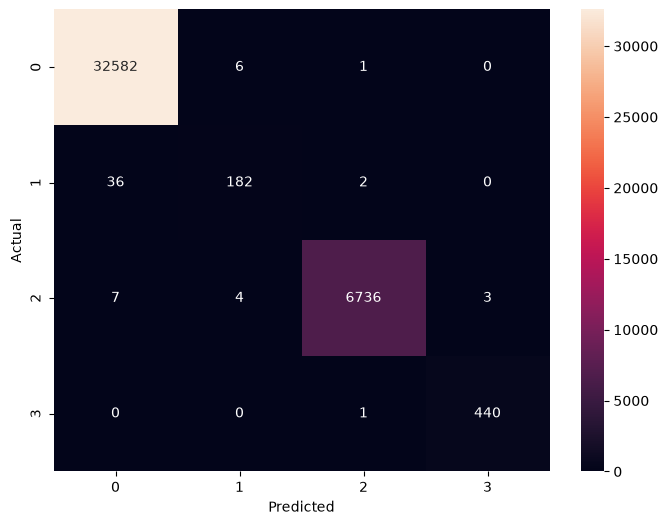

In [119]:
#=========CORRELATION HEATMAP==============

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Generating Learning Curve for XGBoost CKD Severity Model
Learning Curve Dataset Shape : (50000, 94)


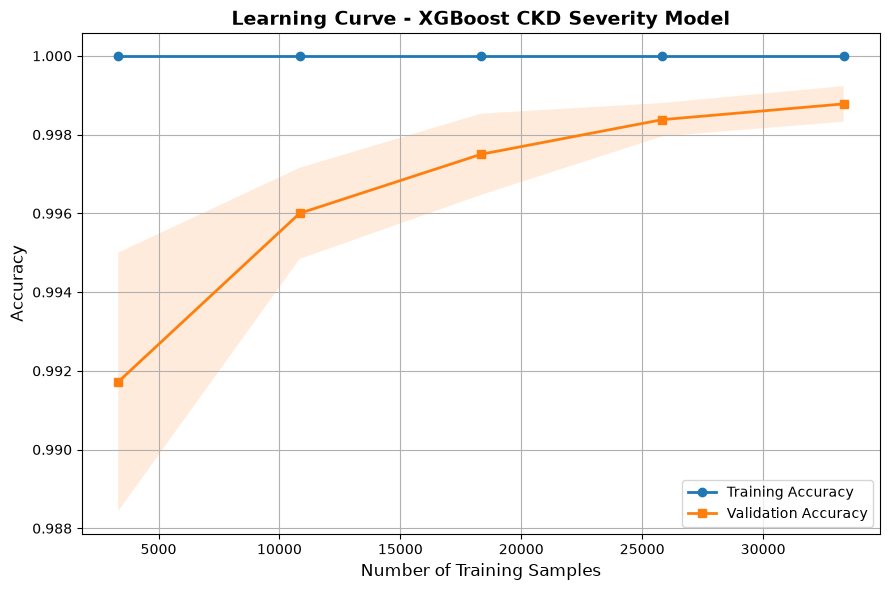


Training Accuracy
[1. 1. 1. 1. 1.]

Validation Accuracy
[0.99172005 0.99600003 0.99750002 0.99838001 0.99878001]
Learning Curve Generated Successfully


In [ ]:
# =============================================================================
# STEP XX : LEARNING CURVE - XGBOOST CKD SEVERITY MODEL
# =============================================================================

from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("Generating Learning Curve for XGBoost CKD Severity Model")
print("=" * 70)

# =============================================================================
# Create Representative Sample
# =============================================================================

X_lc, _, y_lc, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=50000,
    stratify=y_train_smote,
    random_state=42
)

print(f"Learning Curve Dataset Shape : {X_lc.shape}")

# =============================================================================
# Compute Learning Curve
# =============================================================================

train_sizes, train_scores, val_scores = learning_curve(
    estimator=xgb_model,
    X=X_lc,
    y=y_lc,
    cv=3,
    scoring="accuracy",
    n_jobs=1,                     # Avoid nested parallelism
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42
)

# =============================================================================
# Mean Accuracy
# =============================================================================

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# =============================================================================
# Plot Learning Curve
# =============================================================================

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

# Standard deviation bands
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15
)

plt.title(
    "Learning Curve - XGBoost CKD Severity Model",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Number of Training Samples",
    fontsize=12
)

plt.ylabel(
    "Accuracy",
    fontsize=12
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# =============================================================================
# Accuracy Table
# =============================================================================

print("\nTraining Accuracy")
print(train_mean)

print("\nValidation Accuracy")
print(val_mean)

print("=" * 70)
print("Learning Curve Generated Successfully")
print("=" * 70)



Multiclass ROC-AUC: 0.9995525968905183


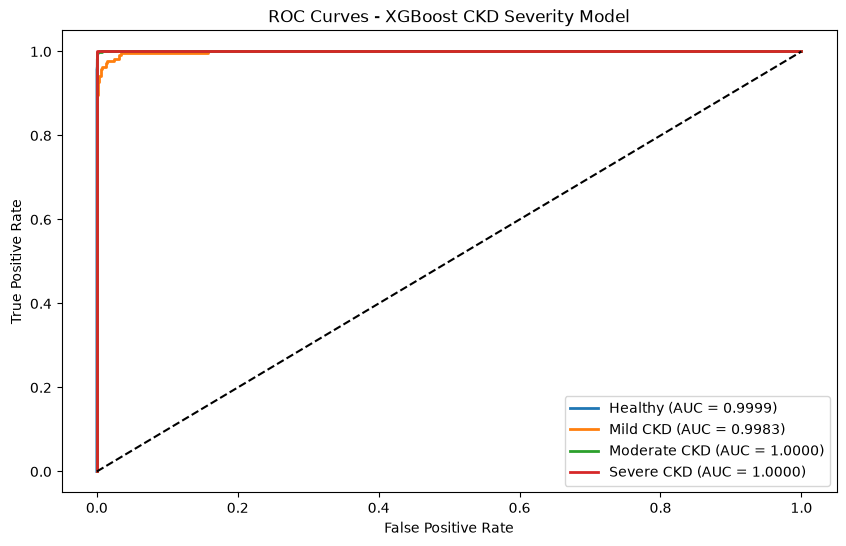

In [127]:
#================Multiclass ROC-AUC===================

from sklearn.metrics import roc_auc_score

xgb_prob = xgb_model.predict_proba(
    X_test_scaled
)

auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class='ovr'
)

print("Multiclass ROC-AUC:", auc)

# =============================================================================
# MULTICLASS ROC-AUC CURVE (XGBOOST)
# =============================================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = xgb_model.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_prob = xgb_model.predict_proba(X_test_scaled)

plt.figure(figsize=(10,6))

class_names = {
    0:"Healthy",
    1:"Mild CKD",
    2:"Moderate CKD",
    3:"Severe CKD"
}

for i, cls in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{class_names[cls]} (AUC = {roc_auc:.4f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - XGBoost CKD Severity Model")
plt.legend(loc="lower right")

plt.show()

In [128]:
# =============================================================================
# MODEL COMPARISON TABLE
# =============================================================================

import pandas as pd

comparison_df = pd.DataFrame({

    "Model": [
        "Ordinal Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Weighted Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],

    "Weighted Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],

    "Weighted F1": [
        f1,
        rf_f1,
        xgb_f1
    ],

    "Macro Precision": [
        macro_precision,
        rf_macro_precision,
        xgb_macro_precision
    ],

    "Macro Recall": [
        macro_recall,
        rf_macro_recall,
        xgb_macro_recall
    ],

    "Macro F1": [
        macro_f1,
        rf_macro_f1,
        xgb_macro_f1
    ],

    "QWK": [
        qwk,
        rf_qwk,
        xgb_qwk
    ]

})

comparison_df.sort_values(
    by="Macro F1",
    ascending=False
)
comparison_df = comparison_df.round(4)

comparison_df



,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,QWK
0,Ordinal Logistic Regression,0.9228,0.9921,0.9228,0.9543,0.7411,0.8859,0.7372,0.9383
1,Random Forest,0.9982,0.9981,0.9982,0.9980,0.9846,0.9289,0.9532,0.9986
2,XGBoost,0.9985,0.9985,0.9985,0.9985,0.9848,0.9557,0.9692,0.9984


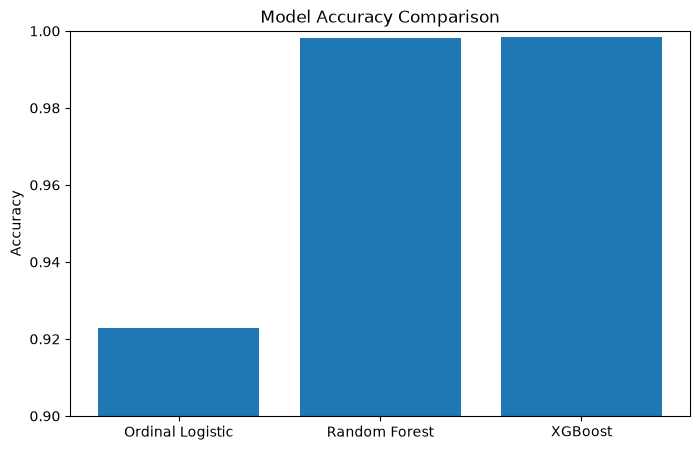

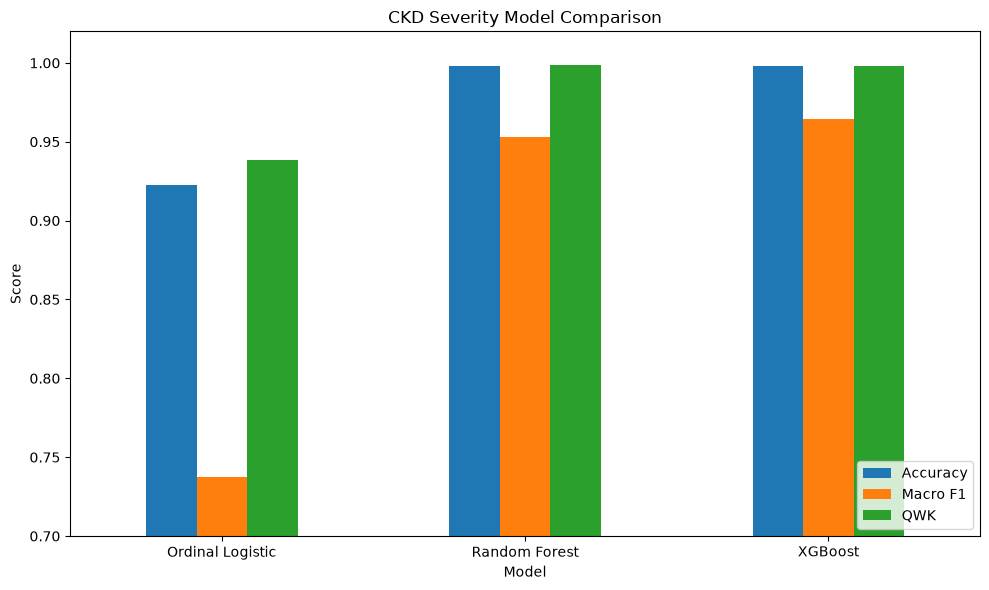

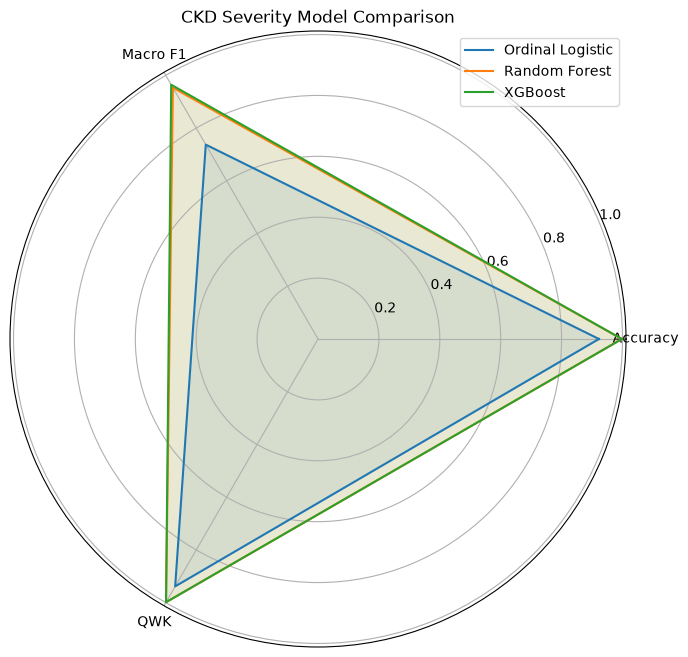

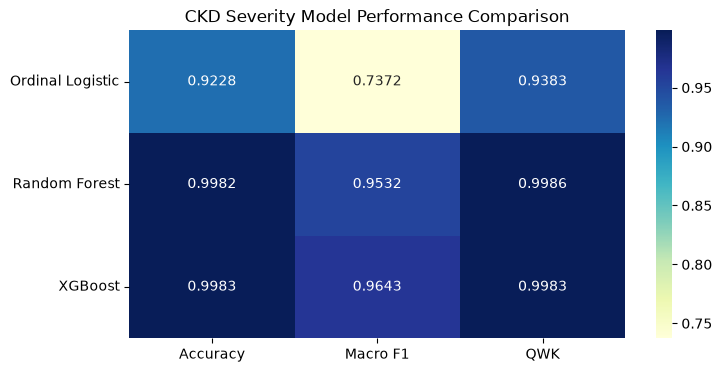

In [129]:
#  Model Comparison Bar Chart

import matplotlib.pyplot as plt

models = [
    "Ordinal Logistic",
    "Random Forest",
    "XGBoost"
]

accuracy = [
    0.9228,
    0.9982,
    0.9983
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0.90,1.00)

plt.show()

#=====Compare Multiple Metrics Together======

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': [
        'Ordinal Logistic',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [0.9228, 0.9982, 0.9983],
    'Macro F1': [0.7372, 0.9532, 0.9643],
    'QWK': [0.9383, 0.9986, 0.9983]
})

results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("CKD Severity Model Comparison")
plt.ylabel("Score")
plt.ylim(0.70,1.02)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

#==========Radar chart==============


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metrics = ['Accuracy','Macro F1','QWK']

ordinal = [0.9228,0.7372,0.9383]
rf = [0.9982,0.9532,0.9986]
xgb = [0.9983,0.9643,0.9983]

angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
).tolist()

angles += angles[:1]

ordinal += ordinal[:1]
rf += rf[:1]
xgb += xgb[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.plot(angles, ordinal, label='Ordinal Logistic')
ax.fill(angles, ordinal, alpha=0.1)

ax.plot(angles, rf, label='Random Forest')
ax.fill(angles, rf, alpha=0.1)

ax.plot(angles, xgb, label='XGBoost')
ax.fill(angles, xgb, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

plt.title("CKD Severity Model Comparison")
plt.legend(loc='upper right')

plt.show()

#===========Heatmap of Metrics==============


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Accuracy':[0.9228,0.9982,0.9983],
    'Macro F1':[0.7372,0.9532,0.9643],
    'QWK':[0.9383,0.9986,0.9983]
},
index=[
    'Ordinal Logistic',
    'Random Forest',
    'XGBoost'
])

plt.figure(figsize=(8,4))

sns.heatmap(
    comparison,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu"
)

plt.title("CKD Severity Model Performance Comparison")

plt.show()


In [130]:
# ===========Save final model===================

import joblib

joblib.dump(
    xgb_model,
    "CKD_Severity_XGBoost_Model.pkl"
)

print("Model Saved Successfully")

# ===========save preprocessing objects===============

import joblib

# Save model
joblib.dump(xgb_model, "CKD_Severity_XGBoost.pkl")

# Save preprocessing objects
joblib.dump(scaler, "scaler.pkl")
joblib.dump(num_imputer, "num_imputer.pkl")

print("Model Saved Successfully")

Model Saved Successfully
Model Saved Successfully
